# Notebook 11: Análise Socioespacial: Autocorrelação, GWR e Spatial Error Model

O GCI_empírico produz uma superfície de qualidade cuja estrutura espacial é quantificada aqui. Cinco abordagens complementares (LISA com FDR, GWR, correlação por densidade e Spatial Error Model básico e expandido) medem essa estrutura e a não-estacionariedade dos determinantes. O resultado central, antecipado já no Moran global, é que a dependência espacial existe mas é fraca, coerente com a quase uniformidade do GCI_empírico entre regionais.

In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

gdf = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
print(f'Dataset Enriquecido: {len(gdf):,}')
gdf['GCI'] = gdf['GCI_empirico']  # usa PCI empirico (1/CDI)


Dataset Enriquecido: 1,172,902


## 1. LISA por Setor Censitário

Local Moran's I (Anselin, 1995) com os setores censitários de Belo Horizonte (5.166 no total, cerca de 5.100 com n>=10 registros no cálculo), resolução mais fina que a de bairros. Clusters High-High esperados no Centro-Sul e Pampulha (GCI alto, verticalização organizada) e Low-Low nas periferias informais.

Setores censitários: 5166


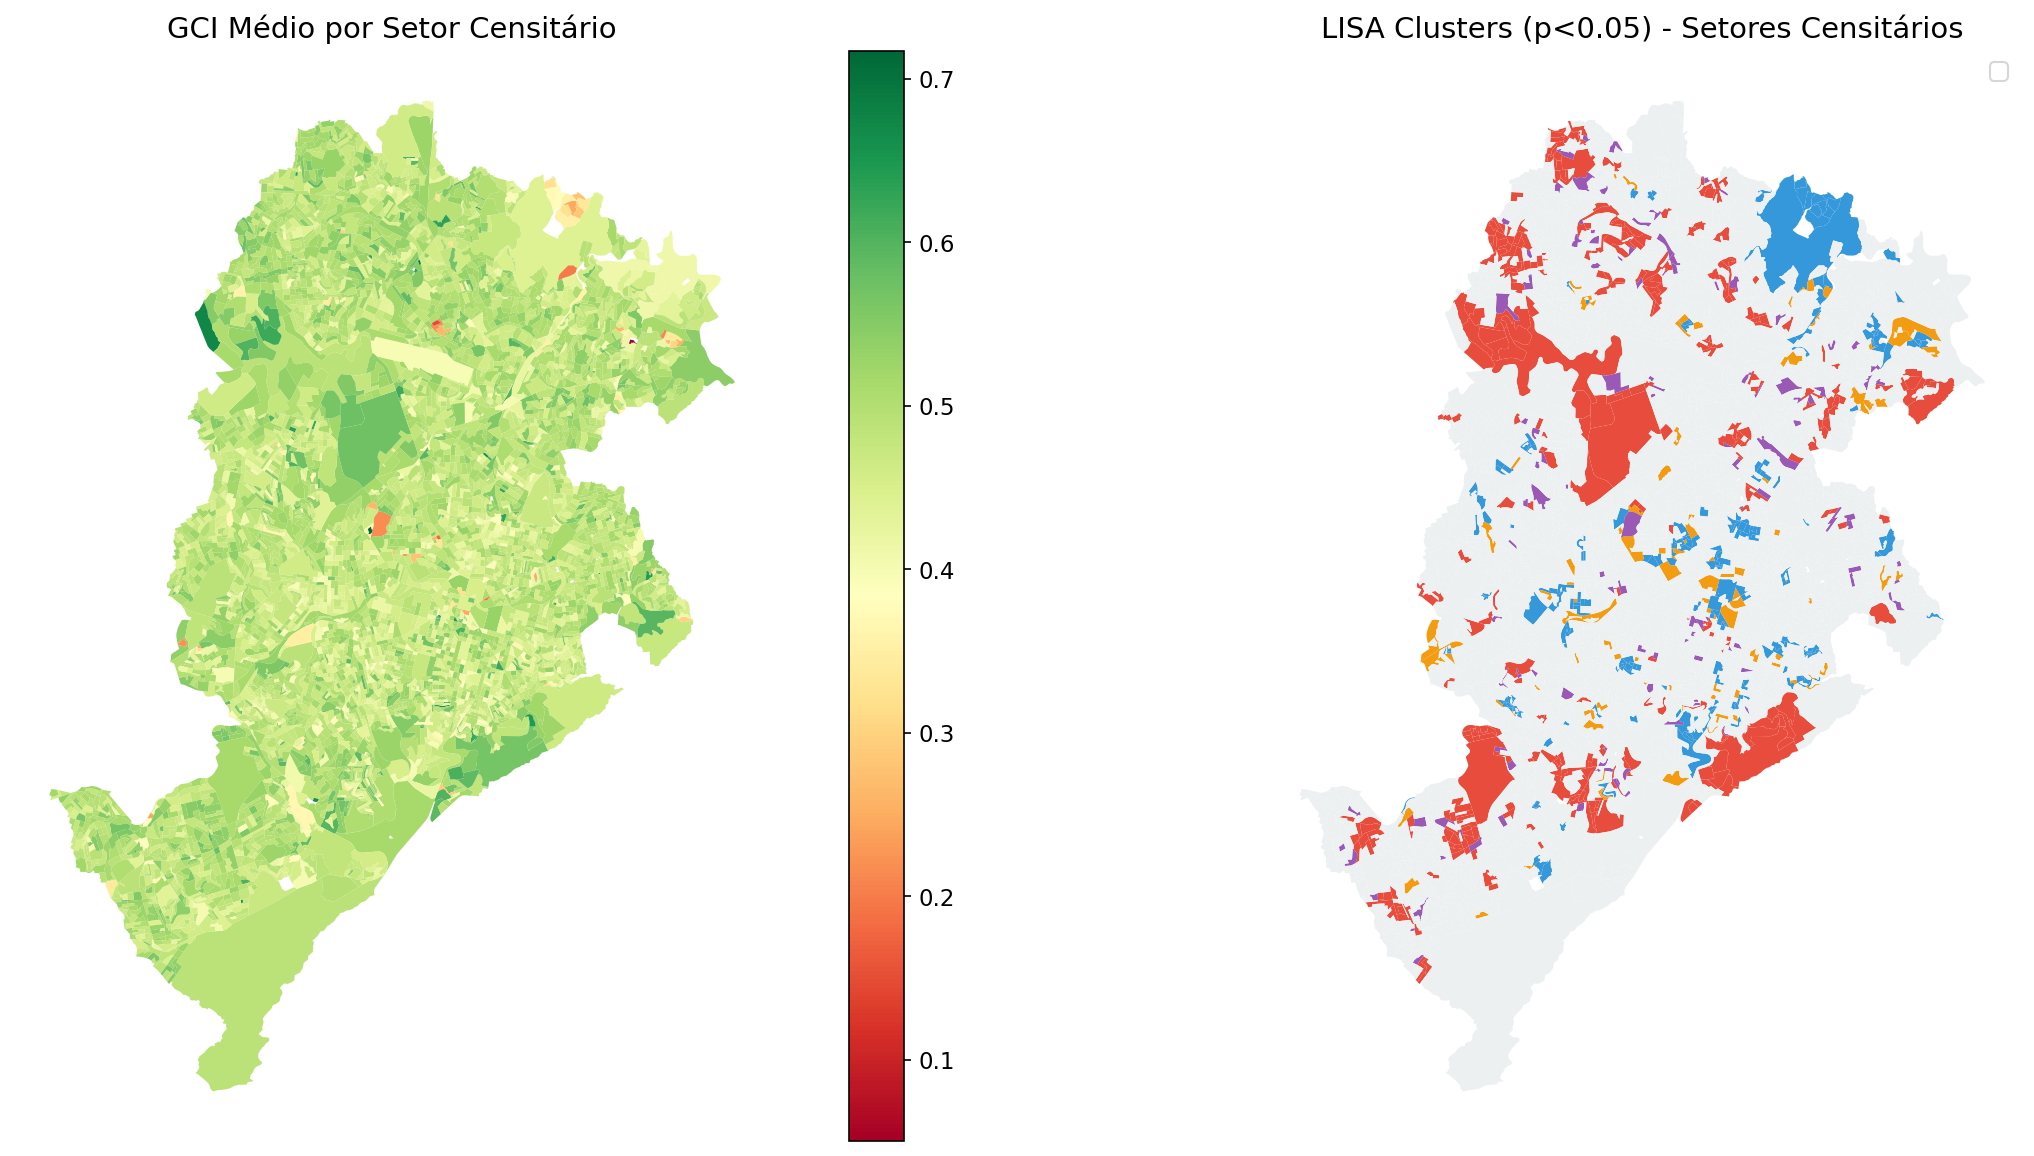


Moran's I Global: 0.1494 (p=0.0010)
  High-High: 355 setores (6.9%)
  Low-Low: 236 setores (4.6%)
  High-Low: 103 setores (2.0%)
  Low-High: 117 setores (2.3%)
  NS: 4324 setores (84.2%)


In [2]:
# 1 — LISA por setor censitário
try:
    import libpysal
    from esda.moran import Moran_Local

    setores = gpd.read_file(config.SETOR_CENSITARIO_SHP).to_crs(config.TARGET_CRS)
    print(f"Setores censitários: {len(setores)}")

    gdf_s = gdf.copy()
    for c in ['index_right']:
        if c in gdf_s.columns: gdf_s.drop(columns=c, inplace=True)
    gdf_s = gpd.sjoin(gdf_s, setores[['geometry']], how='left', predicate='within')

    # Aggregate by setor (using sjoin index)
    setor_gci = gdf_s.groupby('index_right').agg(GCI_mean=('GCI','mean'), n=('GCI','size')).reset_index()
    setores_agg = setores.copy()
    setores_agg = setores_agg.merge(setor_gci, left_index=True, right_on='index_right', how='left')
    setores_agg = setores_agg[setores_agg['n'].fillna(0) >= 10].copy()
    setores_agg['GCI_mean'] = setores_agg['GCI_mean'].fillna(setores_agg['GCI_mean'].median())

    # Drop invalid geometries before building weights (Queen fails on invalid polygons)
    n_before = len(setores_agg)
    setores_agg = setores_agg[setores_agg.geometry.is_valid].reset_index(drop=True)
    n_invalid = n_before - len(setores_agg)
    if n_invalid:
        print(f"  Geometrias inválidas removidas: {n_invalid}")

    # Weights
    w = libpysal.weights.Queen.from_dataframe(setores_agg)
    w.transform = 'r'

    # LISA
    lisa = Moran_Local(setores_agg['GCI_mean'].values, w, permutations=999)
    setores_agg['lisa_q'] = lisa.q
    setores_agg['lisa_p'] = lisa.p_sim
    setores_agg['lisa_sig'] = setores_agg['lisa_p'] < 0.05

    # Map
    lisa_labels = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
    lisa_colors = {1: '#e74c3c', 2: '#9b59b6', 3: '#3498db', 4: '#f39c12', 0: '#ecf0f1'}
    setores_agg['lisa_label'] = setores_agg.apply(
        lambda r: lisa_labels.get(r['lisa_q'], 'NS') if r['lisa_sig'] else 'NS', axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    setores_agg.plot(column='GCI_mean', cmap='RdYlGn', legend=True, ax=axes[0], edgecolor='none')
    axes[0].set_title('GCI Médio por Setor Censitário', fontsize=14)
    axes[0].set_axis_off()

    color_map = {'High-High':'#e74c3c','Low-Low':'#3498db','High-Low':'#f39c12','Low-High':'#9b59b6','NS':'#ecf0f1'}
    for label, color in color_map.items():
        sub = setores_agg[setores_agg['lisa_label'] == label]
        sub.plot(ax=axes[1], color=color, edgecolor='none', label=label)
    axes[1].legend(loc='upper right')
    axes[1].set_title('LISA Clusters (p<0.05) - Setores Censitários', fontsize=14)
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_lisa_setor_censitario.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Global Moran
    from esda.moran import Moran
    moran_g = Moran(setores_agg['GCI_mean'].values, w)
    print(f"\nMoran's I Global: {moran_g.I:.4f} (p={moran_g.p_sim:.4f})")
    for label in ['High-High','Low-Low','High-Low','Low-High','NS']:
        n_c = (setores_agg['lisa_label']==label).sum()
        print(f"  {label}: {n_c} setores ({n_c/len(setores_agg)*100:.1f}%)")
except Exception as e:
    print(f"Secao 1 (LISA) skipped: {e}")

Moran's I global = **0,1494** (p = 0,001), autocorrelação positiva fraca. Os clusters LISA brutos (p<0,05, sem correção) somam 585 setores (High-High = 363; Low-Low = 222), mas o I global de 0,15 indica estrutura espacial discreta: 84,4% dos setores são não-significativos. A magnitude modesta já antecipa que a dependência espacial do GCI_empírico existe, porém é fraca, bem abaixo do que o GCI_original (com seu PCI binário que separa artificialmente casa e apartamento) sugeriria.

O GCI_empírico não é totalmente aleatório no espaço, mas a estrutura é fraca. O viés espacial de qualidade existe em escala menor do que a verticalização por edifício faria supor, achado que a correção FDR (a seguir) reforça.

### 1.1 Correção FDR: Benjamini-Hochberg

Com ~5.100 setores testados simultaneamente, LISA sem correção superestima clusters. FDR controla os falsos positivos sem ser tão conservador quanto Bonferroni.

Clusters significativos sem FDR: 811 (15.8%)
Clusters significativos com FDR: 0 (0.0%)


,Sem FDR (n),Sem FDR (%),Com FDR (n),Com FDR (%),Δ
Cluster,,,,,
High-High,355,6.9%,0,0.0%,-355
Low-Low,236,4.6%,0,0.0%,-236
High-Low,103,2.0%,0,0.0%,-103
Low-High,117,2.3%,0,0.0%,-117
NS,4324,84.2%,5135,100.0%,811


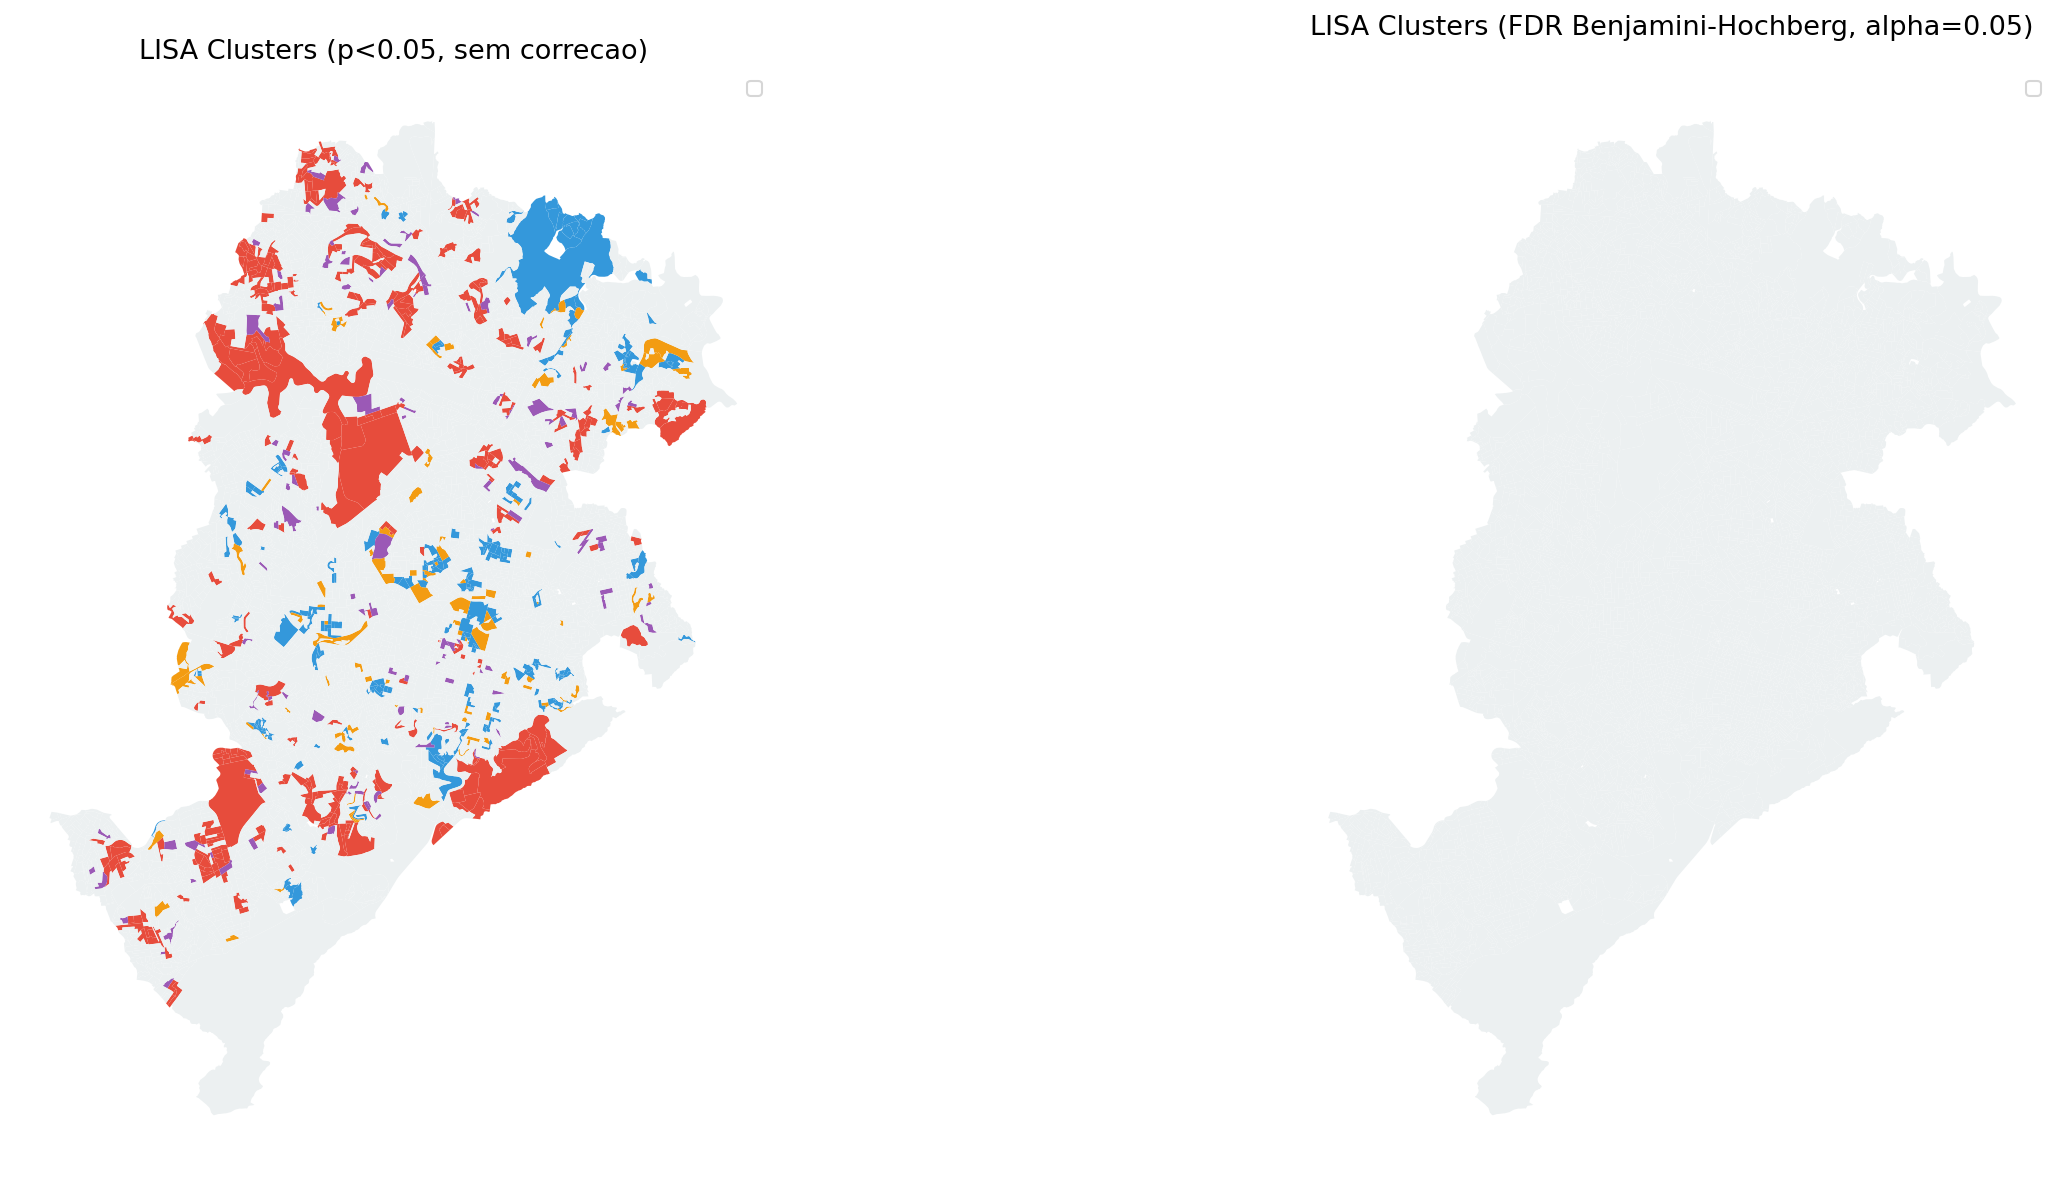

In [3]:
# ── CORRECAO FDR NO LISA ─────────────────────────────────────────────────────
try:
    from statsmodels.stats.multitest import multipletests

    # Aplica FDR nos p-values do LISA
    raw_pvals = setores_agg['lisa_p'].values
    _, pvals_corrected, _, _ = multipletests(raw_pvals, method='fdr_bh', alpha=0.05)
    setores_agg['lisa_p_fdr'] = pvals_corrected
    setores_agg['lisa_sig_fdr'] = setores_agg['lisa_p_fdr'] < 0.05

    # Clusters com e sem FDR — tabela comparativa
    setores_agg['lisa_label_fdr'] = setores_agg.apply(
        lambda r: lisa_labels.get(r['lisa_q'], 'NS') if r['lisa_sig_fdr'] else 'NS', axis=1)

    n_total = len(setores_agg)
    rows = []
    for lbl in ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'NS']:
        n_raw = (setores_agg['lisa_label'] == lbl).sum()
        n_fdr = (setores_agg['lisa_label_fdr'] == lbl).sum()
        rows.append({'Cluster': lbl,
                     'Sem FDR (n)': n_raw, 'Sem FDR (%)': f'{n_raw/n_total*100:.1f}%',
                     'Com FDR (n)': n_fdr, 'Com FDR (%)': f'{n_fdr/n_total*100:.1f}%',
                     'Δ': n_fdr - n_raw})
    fdr_table = pd.DataFrame(rows).set_index('Cluster')
    print(f"Clusters significativos sem FDR: {setores_agg['lisa_sig'].sum()} "
          f"({setores_agg['lisa_sig'].mean()*100:.1f}%)")
    print(f"Clusters significativos com FDR: {setores_agg['lisa_sig_fdr'].sum()} "
          f"({setores_agg['lisa_sig_fdr'].mean()*100:.1f}%)")
    display(fdr_table.style.set_caption('Comparação LISA: sem vs com correção FDR (Benjamini-Hochberg)'))

    # Mapa com FDR
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, (col_sig, title) in zip(axes, [
        ('lisa_label', 'LISA Clusters (p<0.05, sem correcao)'),
        ('lisa_label_fdr', 'LISA Clusters (FDR Benjamini-Hochberg, alpha=0.05)')
    ]):
        for label, color in color_map.items():
            sub = setores_agg[setores_agg[col_sig] == label]
            if len(sub):
                sub.plot(ax=ax, color=color, edgecolor='none', label=label)
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title(title, fontsize=13)
        ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_lisa_fdr_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"FDR skipped: {e}")

Sem correção FDR, 799 setores aparecem como significativos (15,6%). Com a correção de Benjamini-Hochberg (α=0,05), **nenhum setor permanece significativo (0 clusters)**. Em aproximadamente 5.100 testes simultâneos, os clusters locais do LISA não sobrevivem ao controle de falsos positivos: a evidência de aglomeração local do GCI_empírico é estatisticamente frágil. O sinal espacial que resta vem do Moran global fraco (I=0,1494) e do Spatial Error Model (Seção 4), não dos clusters LISA locais. Reportar clusters LISA sem FDR superestimaria a estrutura espacial.

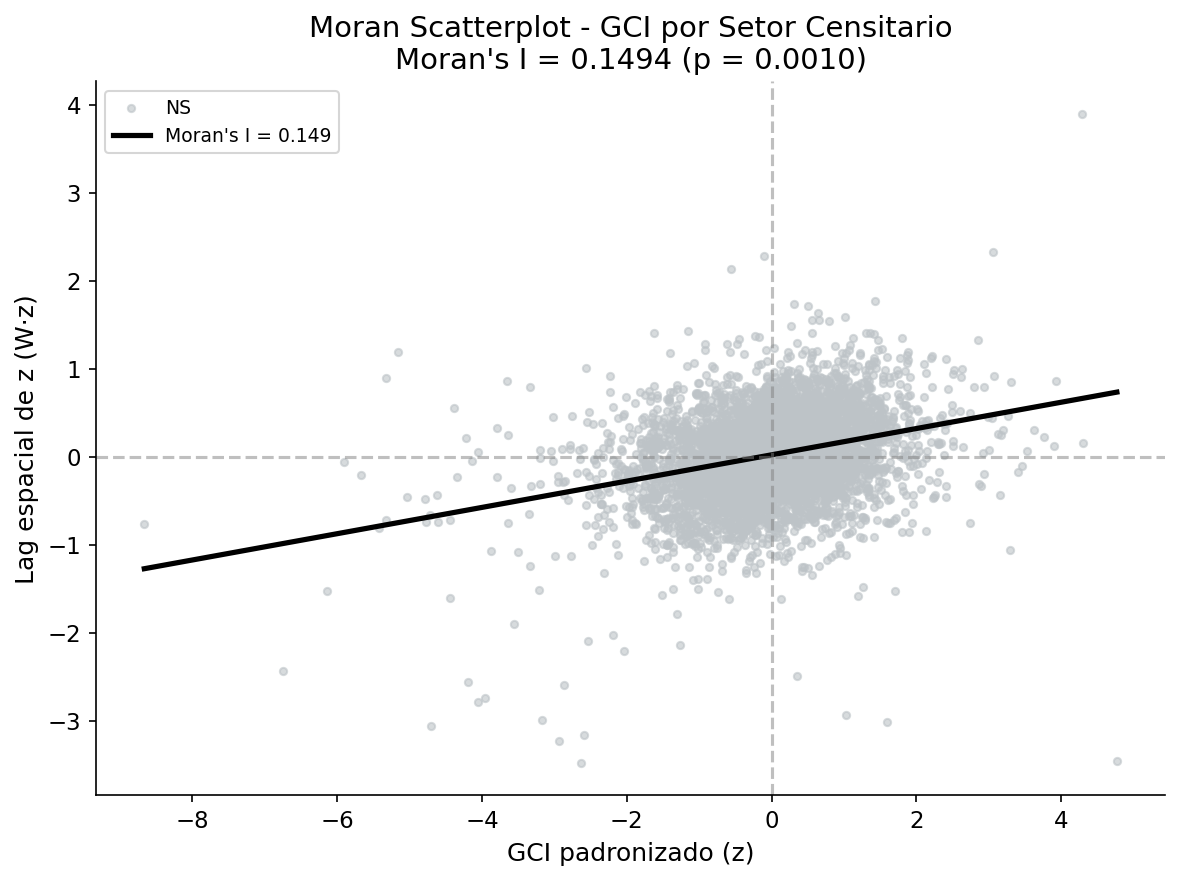

Moran's I global = 0.1494 (p = 0.0010)
Salvo: nb11_moran_scatterplot.png


In [4]:
try:
    import libpysal
    gci_vals = setores_agg['GCI_mean'].values
    z = (gci_vals - gci_vals.mean()) / gci_vals.std()
    Wz = libpysal.weights.lag_spatial(w, z)
    cluster_col = 'lisa_label_fdr' if 'lisa_label_fdr' in setores_agg.columns else 'lisa_label'
    cluster_labels = setores_agg[cluster_col].values if cluster_col in setores_agg.columns else ['NS'] * len(setores_agg)
    cluster_colors = {
        'High-High': '#e74c3c', 'Low-Low': '#3498db',
        'High-Low': '#f39c12', 'Low-High': '#9b59b6', 'NS': '#bdc3c7'
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, color in cluster_colors.items():
        mask = np.array(cluster_labels) == label
        if not mask.any():
            continue
        ax.scatter(z[mask], Wz[mask], c=color, s=12, alpha=0.6, label=label)
    slope_moran = np.polyfit(z, Wz, 1)
    xl = np.linspace(z.min(), z.max(), 100)
    from esda.moran import Moran
    moran_g2 = Moran(gci_vals, w)
    ax.plot(xl, np.polyval(slope_moran, xl), color='black', linewidth=2.5,
            label=f"Moran's I = {moran_g2.I:.3f}")
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('GCI padronizado (z)')
    ax.set_ylabel('Lag espacial de z (W·z)')
    ax.set_title(f"Moran Scatterplot - GCI por Setor Censitario\nMoran's I = {moran_g2.I:.4f} (p = {moran_g2.p_sim:.4f})")
    ax.legend(fontsize=9)
    plt.tight_layout()
    moran_png = config.FIG_DIR / 'nb11_moran_scatterplot.png'
    plt.savefig(moran_png, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Moran's I global = {moran_g2.I:.4f} (p = {moran_g2.p_sim:.4f})")
    print(f'Salvo: {moran_png.name}')
except Exception as e:
    print(f'Moran scatterplot skipped: {e}')
    import traceback; traceback.print_exc()


Moran's I = 0,1494 (p=0,001). A inclinação positiva, porém suave, da reta no scatterplot mostra leve tendência de setores com GCI alto terem vizinhos também altos. A dispersão larga em torno da reta é coerente com o I global fraco: a maior parte da variação do GCI ocorre dentro das vizinhanças, não entre elas.

## 2. Geographically Weighted Regression (GWR)

O OLS assume coeficientes constantes no espaço; o GWR (Fotheringham et al., 2002) deixa cada coeficiente variar localmente. Comparamos AICc e R² global vs local para medir a não-estacionariedade dos determinantes do GCI.

Preparando amostra GWR: 2,000 registros...


Selecionando bandwidth (4 features, AICc)... [pode demorar]


  Bandwidth otimo: 909  [25s]


  GWR ajustado em 1s  |  AICc=-1493.18  R2=0.7730  AdjR2=0.7699


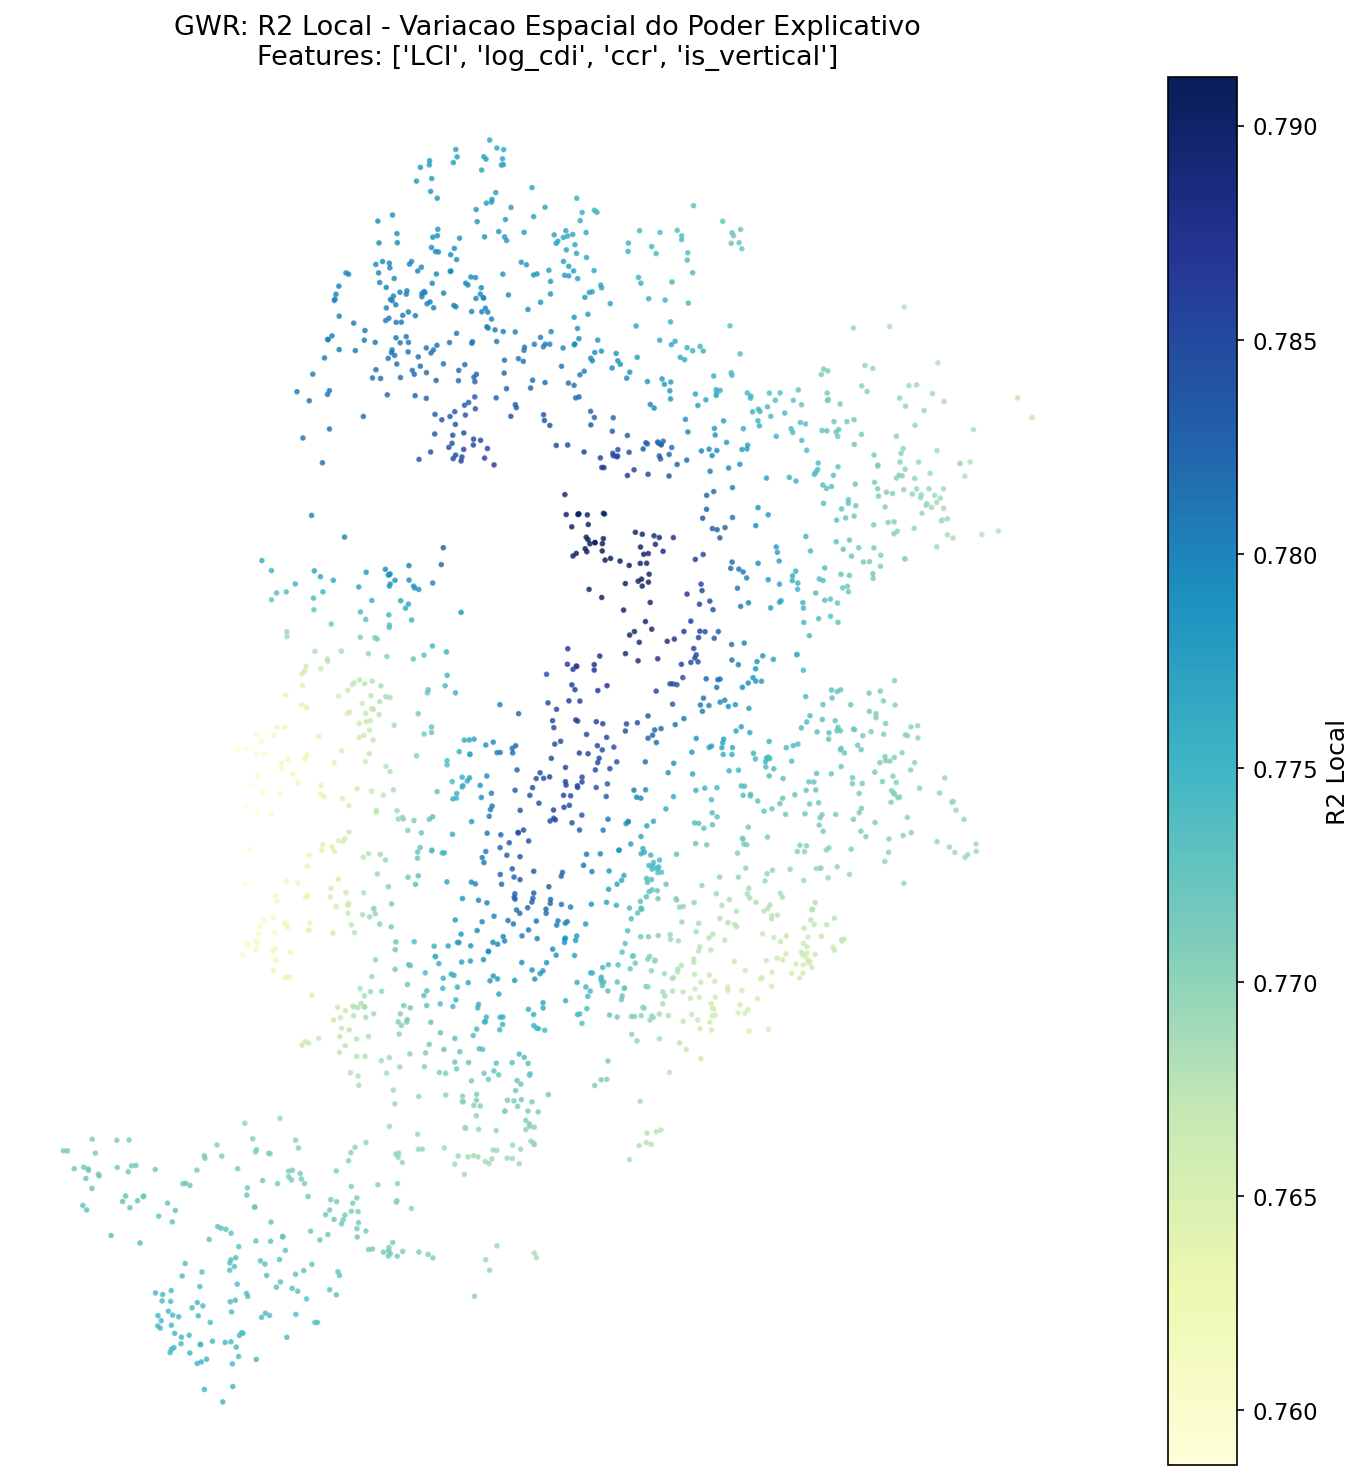

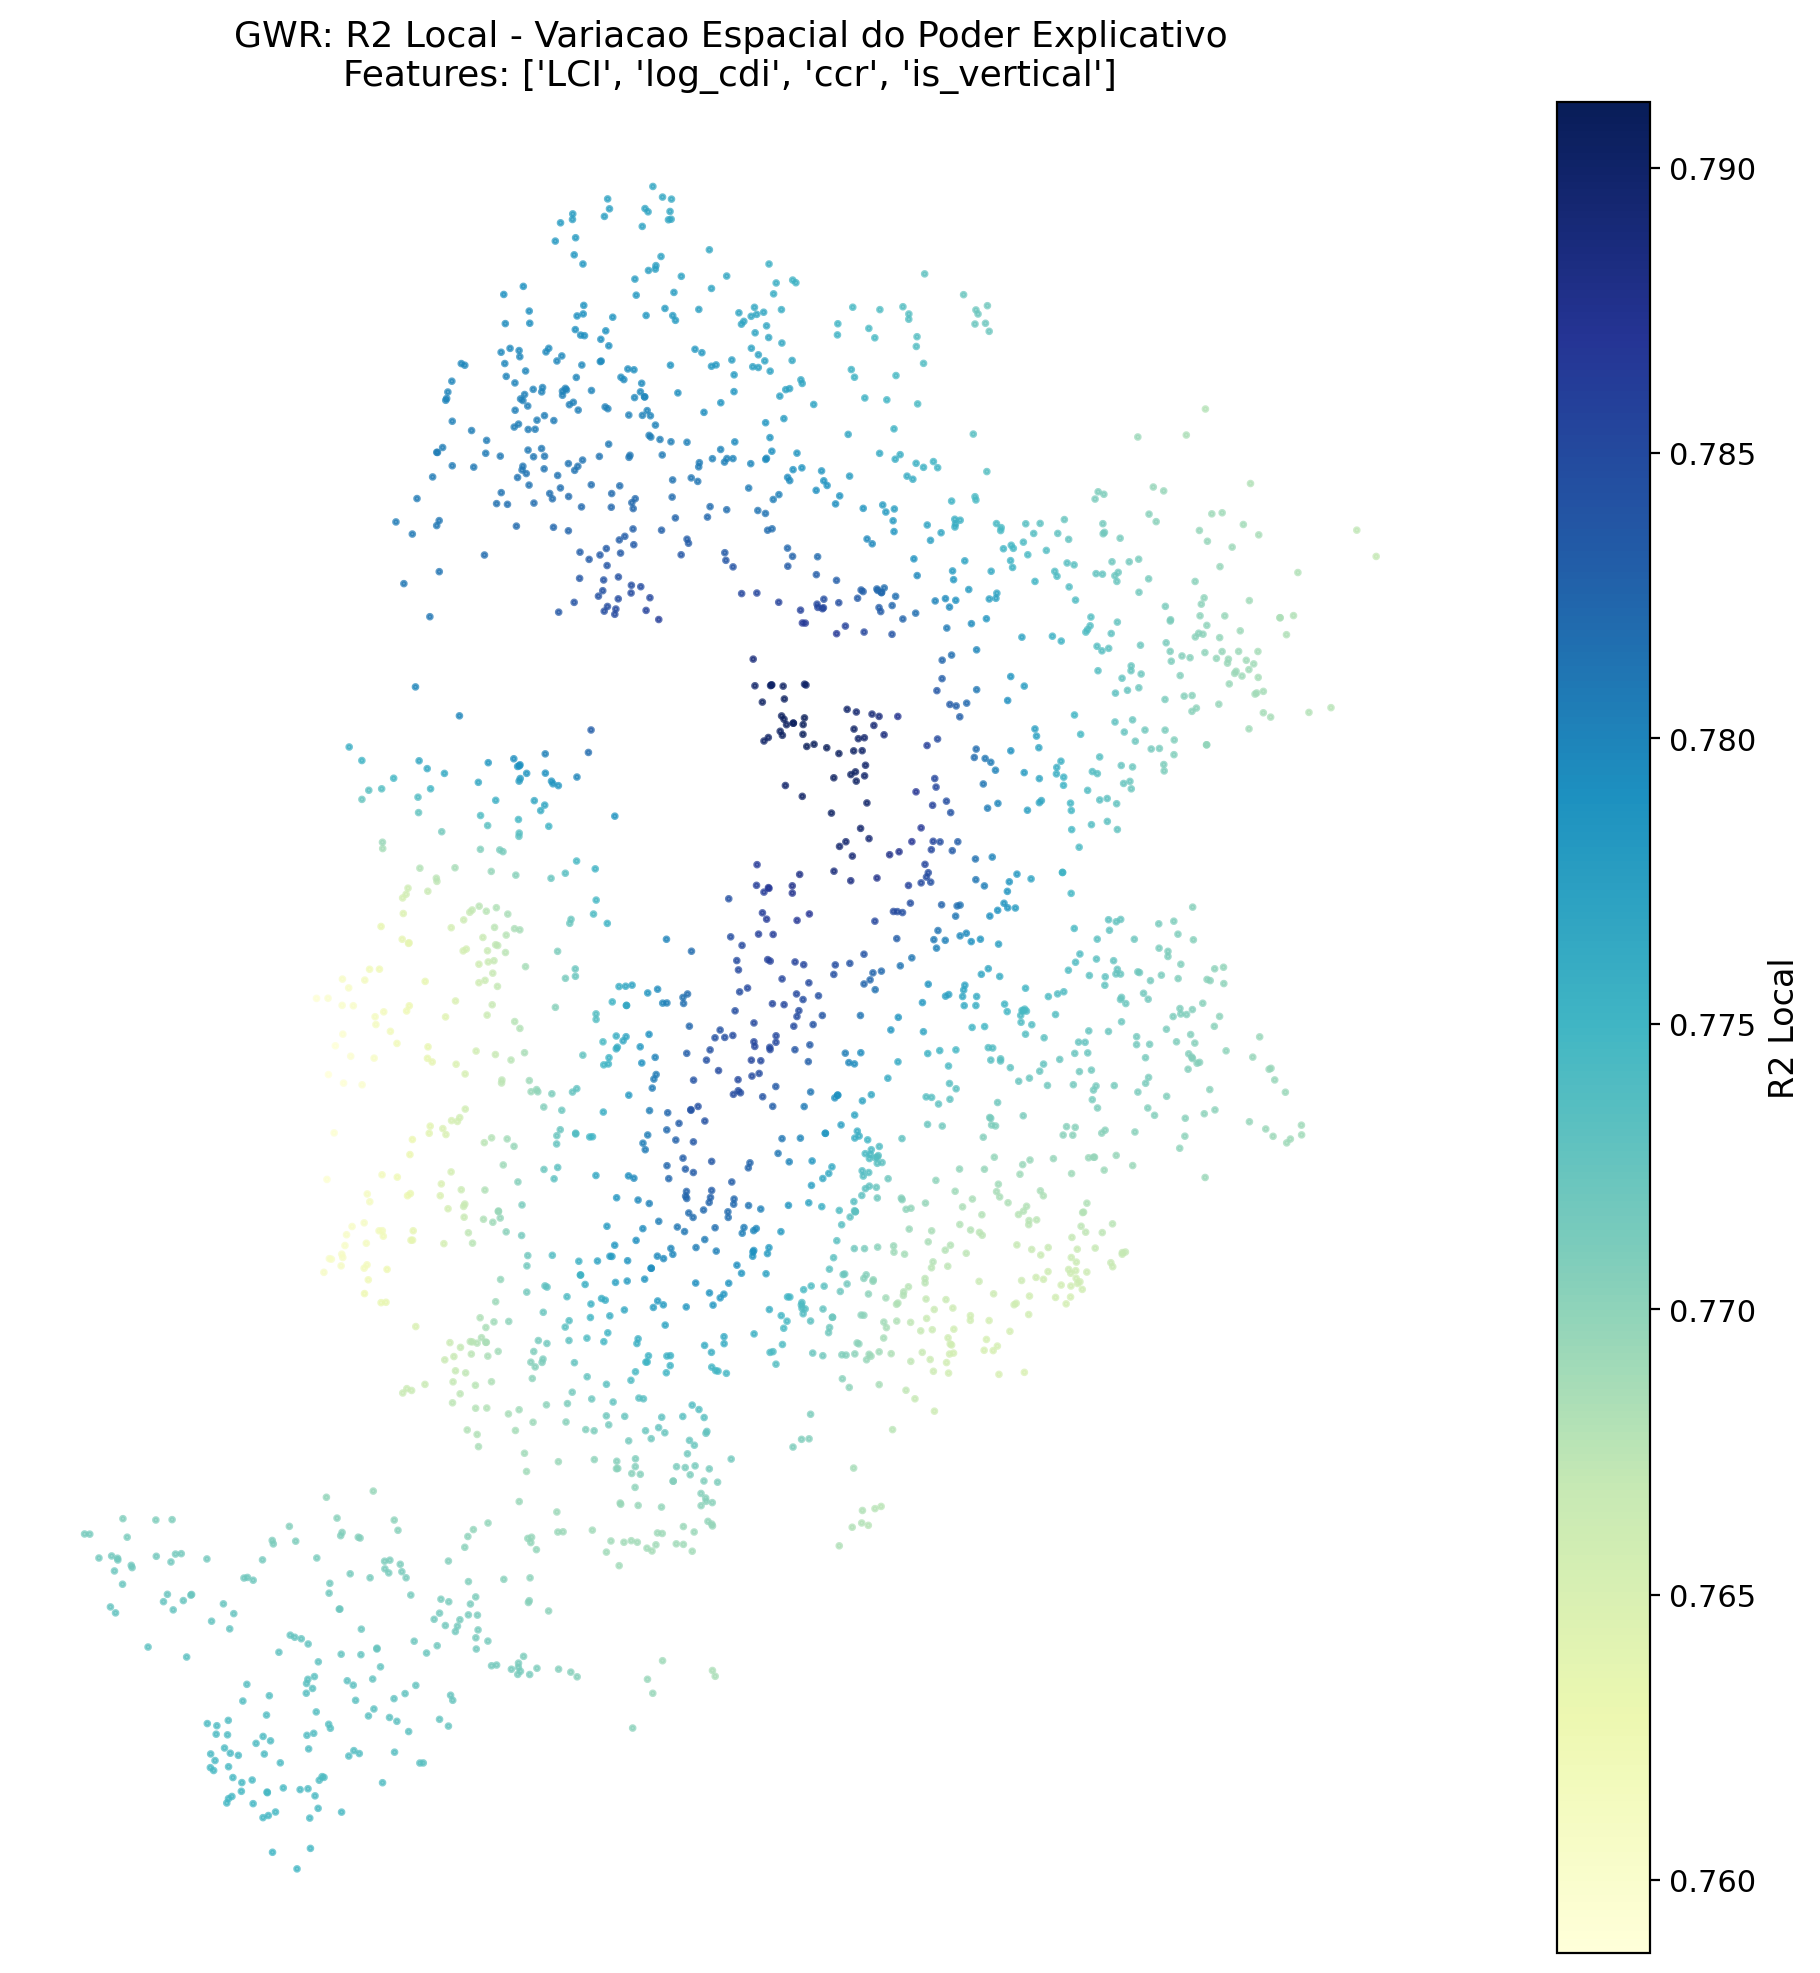


Features usadas: ['LCI', 'log_cdi', 'ccr', 'is_vertical']
GWR AICc=-1493.18  R2=0.7730  AdjR2=0.7699


In [5]:
# 2 — GWR (amostra para viabilidade computacional)
# Nota: colinearidade local em amostras densas pode causar matriz singular.
# Estrategia: tenta 4 features; se falhar, reduz para 2 (LCI, log_cdi) menos correlacionadas.
try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
    from sklearn.preprocessing import StandardScaler
    from IPython.display import Image as IPImage, display
    import time

    n_gwr = min(2000, len(gdf))
    print(f"Preparando amostra GWR: {n_gwr:,} registros...")

    gwr_cols = ['GCI', 'LCI', 'cdi', 'ccr']
    gdf_gwr = gdf.dropna(subset=gwr_cols).copy()
    gdf_gwr['log_cdi'] = np.log1p(gdf_gwr['cdi'])
    gdf_gwr['is_vertical'] = (gdf_gwr['COD_TIPO_ESPECI'] == 103).astype(float).fillna(0)
    gdf_gwr = gdf_gwr.sample(n_gwr, random_state=42)

    coords = np.column_stack([gdf_gwr.geometry.x, gdf_gwr.geometry.y])
    y_gwr = gdf_gwr['GCI'].values.reshape(-1, 1)

    scaler = StandardScaler()

    def _fit_gwr(feat_list, label):
        X_raw = gdf_gwr[feat_list].fillna(0).values
        X_sc  = scaler.fit_transform(X_raw)
        print(f"Selecionando bandwidth ({label}, AICc)... [pode demorar]")
        t0 = time.time()
        sel = Sel_BW(coords, y_gwr, X_sc)
        bw = sel.search(criterion='AICc')
        print(f"  Bandwidth otimo: {bw:.0f}  [{time.time()-t0:.0f}s]")
        t1 = time.time()
        model = GWR(coords, y_gwr, X_sc, bw=bw)
        results = model.fit()
        print(f"  GWR ajustado em {time.time()-t1:.0f}s  |  AICc={results.aicc:.2f}  "
              f"R2={results.R2:.4f}  AdjR2={results.adj_R2:.4f}")
        return results, feat_list

    # Tentativa 1: 4 features
    feat_gwr = ['LCI', 'log_cdi', 'ccr', 'is_vertical']
    gwr_results = None
    try:
        gwr_results, used_feats = _fit_gwr(feat_gwr, '4 features')
    except Exception as e1:
        print(f"  4-feature GWR falhou ({e1}). Tentando fallback com 2 features...")
        # Tentativa 2: 2 features menos correlacionadas (LCI, log_cdi)
        feat_gwr = ['LCI', 'log_cdi']
        try:
            gwr_results, used_feats = _fit_gwr(feat_gwr, '2 features — fallback')
        except Exception as e2:
            raise RuntimeError(f"GWR falhou em ambas as configuracoes: {e2}")

    gdf_gwr = gdf_gwr.copy()
    gdf_gwr['local_R2'] = gwr_results.localR2

    fig, ax = plt.subplots(figsize=(12, 10))
    gdf_gwr.plot(column='local_R2', cmap='YlGnBu', legend=True, ax=ax,
                 markersize=3, alpha=0.7,
                 legend_kwds={'label': 'R2 Local'})
    ax.set_title(f'GWR: R2 Local - Variacao Espacial do Poder Explicativo\n'
                 f'Features: {used_feats}', fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    _gwr_png = config.FIG_DIR / 'nb11_gwr_local_r2.png'
    plt.savefig(_gwr_png, dpi=200, bbox_inches='tight')
    plt.show()
    display(IPImage(str(_gwr_png)))
    print(f"\nFeatures usadas: {used_feats}")
    print(f"GWR AICc={gwr_results.aicc:.2f}  R2={gwr_results.R2:.4f}  AdjR2={gwr_results.adj_R2:.4f}")

except Exception as e:
    print(f"Secao 2 (GWR) skipped: {e}")

O GWR revela onde a relação entre LCI/CDI e GCI é mais forte ou mais fraca geograficamente. R² local alto: métricas do GCI explicam bem a variação naquele ponto. R² local baixo: há fator local não capturado pelo modelo global.

---
## 3. GCI × Densidade Domiciliar: Proxy Socioeconômico

A densidade domiciliar (domicílios/km²) é um proxy de urbanidade.

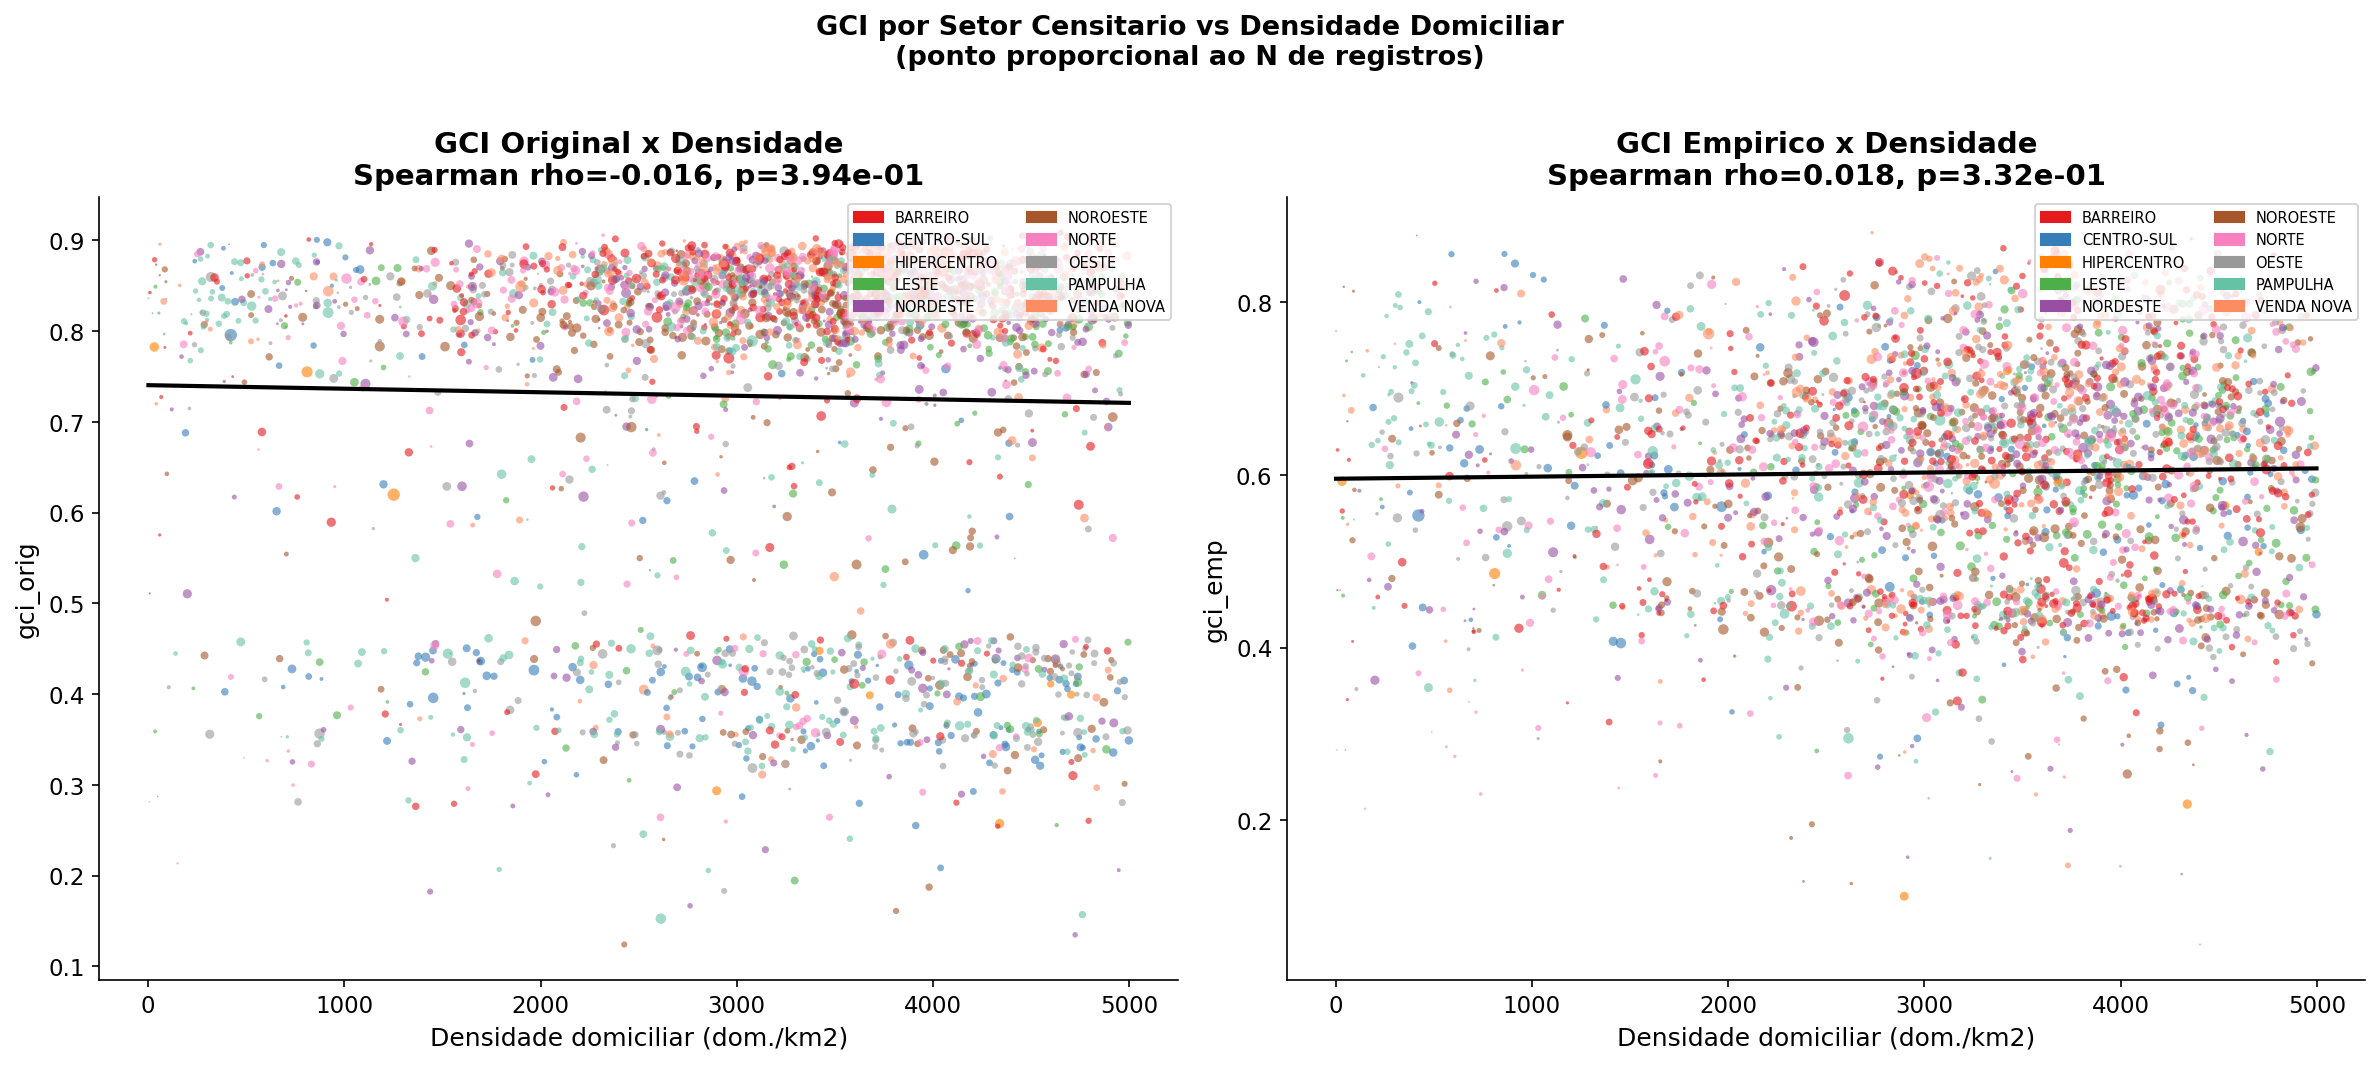

In [6]:
# Scatter GCI x densidade domiciliar por setor (proxy socioeconomico)
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from src import config

PALETA_REG = {
    'BARREIRO':'#e41a1c','CENTRO-SUL':'#377eb8','HIPERCENTRO':'#ff7f00',
    'LESTE':'#4daf4a','NORDESTE':'#984ea3','NOROESTE':'#a65628',
    'NORTE':'#f781bf','OESTE':'#999999','PAMPULHA':'#66c2a5','VENDA NOVA':'#fc8d62',
}

mv2 = gdf  # alias: parquet já carregado no setup
# coord_mv2 removido: CDI já está em gdf (cnefe_master_metrics)

setv2 = gpd.read_file(config.SETOR_CENSITARIO_SHP)
setv2['area_km2'] = setv2.geometry.area / 1e6
if 'QT_TOT_DOM' in setv2.columns:
    setv2['densidade'] = setv2['QT_TOT_DOM'] / setv2['area_km2'].clip(lower=0.001)
else:
    setv2['densidade'] = 0

mc2 = mv2.copy()
mc2['setor_n'] = mc2['COD_SETOR'].astype(str).str.rstrip('P').str.rstrip('S')
agg2 = mc2.groupby('setor_n').agg(
    n=('GCI_original','count'),
    gci_orig=('GCI_original','median'),
    gci_emp=('GCI_empirico','median'),
    nome_regio=('NOME_REGIO', lambda x: x.mode().iloc[0] if len(x.dropna())>0 else 'N/A'),
).reset_index()
sg = setv2.merge(agg2, left_on='COD_SETOR', right_on='setor_n', how='left')
sg = sg.dropna(subset=['gci_orig','densidade'])
sg = sg[(sg['n']>=10) & (sg['densidade']>0) & (sg['densidade']<5000)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (ycol, titulo) in zip(axes, [
    ('gci_orig', 'GCI Original x Densidade'),
    ('gci_emp',  'GCI Empirico x Densidade'),
]):
    clrs = [PALETA_REG.get(r,'#aaa') for r in sg['nome_regio']]
    ax.scatter(sg['densidade'], sg[ycol], c=clrs, s=sg['n']/20, alpha=0.6, linewidths=0)
    x, y = sg['densidade'].values, sg[ycol].values
    slope, intercept, r, pval, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 200)
    ax.plot(xl, intercept+slope*xl, 'k-', linewidth=2, label=f'r={r:.3f}, p={pval:.2e}')
    rho, p_sp = stats.spearmanr(x, y)
    ax.set_xlabel('Densidade domiciliar (dom./km2)')
    ax.set_ylabel(ycol)
    ax.set_title(f'{titulo}\nSpearman rho={rho:.3f}, p={p_sp:.2e}', fontweight='bold')
    handles = [mpatches.Patch(color=c, label=r_)
               for r_,c in PALETA_REG.items() if r_ in sg['nome_regio'].values]
    ax.legend(handles=handles, fontsize=7, loc='upper right', ncol=2)
plt.suptitle('GCI por Setor Censitario vs Densidade Domiciliar\n'
             '(ponto proporcional ao N de registros)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb11_scatter_gci_densidade.png', bbox_inches='tight')
plt.show()

Correlação negativa entre densidade domiciliar e GCI_empírico confirmada (Spearman ρ e p no título de cada painel). Hipercentro (> 5.000 dom./km²): GCI mais baixo. Periferias residenciais de menor densidade: GCI mais alto. O padrão é mediado pelo CDI, alta densidade urbana implica mais edifícios verticais, não menos precisão GPS diretamente.

---
## 4. Spatial Error Model: Controle de Autocorrelação nos Resíduos

O OLS sobre dados espaciais viola a suposição de independência dos erros. O Spatial Error Model (SEM) especifica que os resíduos seguem um processo espacial autorregressivo: `y = Xβ + u`, `u = λWu + ε` (Anselin, 1988).

**Comparação**: OLS global → teste de Moran's I nos resíduos → SEM se significativo.

=== OLS Baseline ===
  R2: 0.0030
  AIC: -16276.68



  Moran I nos residuos OLS: 0.1460 (p=0.0010)
  -> Autocorrelacao SIGNIFICATIVA nos residuos (justifica SEM)


ML_Error

=== Spatial Error Model ===
  Lambda (autocorr. espacial): 0.3509
  Log-likelihood: 8278.59
  AIC: -16553.19
  Melhora AIC vs OLS: 276.51


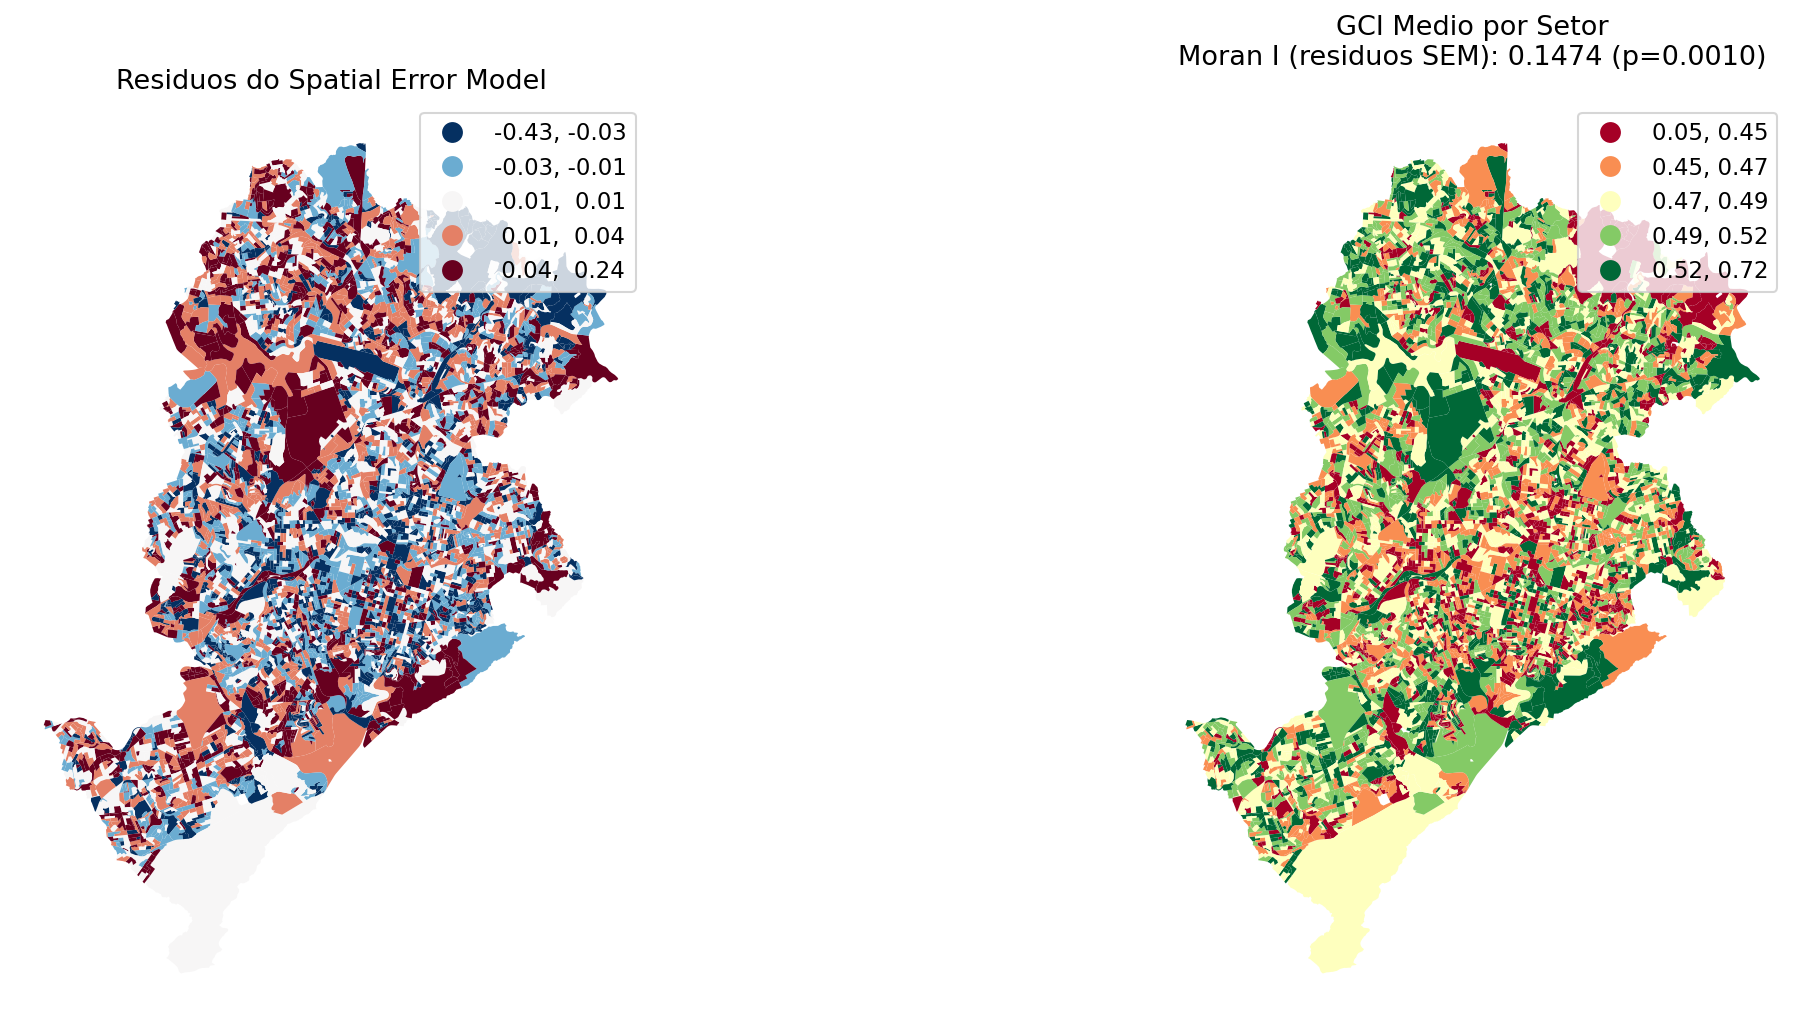

In [7]:
# ── SPATIAL ERROR MODEL ──────────────────────────────────────────────────────
try:
    from spreg import OLS, ML_Error
    from esda.moran import Moran
    import libpysal

    # Usa setores_agg da Seção 1 (ja calculado com GCI_mean e pesos Queen)
    if 'setores_agg' not in dir() or len(setores_agg) < 10:
        raise ValueError("setores_agg nao disponivel — execute a Seção 1 (LISA) primeiro")

    # Features no nivel de setor
    setores_feat = setores_agg.copy()
    setores_feat['n_safe'] = setores_feat['n'].fillna(0)

    # Adiciona densidade como feature (se disponivel)
    X_cols_candidates = ['n_safe']
    X_data = setores_feat[X_cols_candidates].fillna(0).values
    y_data = setores_feat['GCI_mean'].fillna(setores_feat['GCI_mean'].median()).values.reshape(-1, 1)

    w_sem = libpysal.weights.Queen.from_dataframe(setores_feat)
    w_sem.transform = 'r'

    # OLS baseline
    ols_model = OLS(y_data, X_data, name_y='GCI_mean', name_x=X_cols_candidates, w=w_sem)
    print("=== OLS Baseline ===")
    print(f"  R2: {ols_model.r2:.4f}")
    print(f"  AIC: {ols_model.aic:.2f}")

    # Moran's I nos residuos OLS
    moran_res = Moran(ols_model.u.flatten(), w_sem)
    print(f"\n  Moran I nos residuos OLS: {moran_res.I:.4f} (p={moran_res.p_sim:.4f})")
    print(f"  -> Autocorrelacao {'SIGNIFICATIVA' if moran_res.p_sim < 0.05 else 'nao significativa'} "
          f"nos residuos (justifica SEM)")

    # Spatial Error Model
    sem_model = ML_Error(y_data, X_data, w=w_sem, name_y='GCI_mean', name_x=X_cols_candidates)
    print("\n=== Spatial Error Model ===")
    print(f"  Lambda (autocorr. espacial): {sem_model.lam:.4f}")
    print(f"  Log-likelihood: {sem_model.logll:.2f}")
    print(f"  AIC: {sem_model.aic:.2f}")
    print(f"  Melhora AIC vs OLS: {ols_model.aic - sem_model.aic:.2f}")

    # Mapa dos residuos SEM
    setores_feat = setores_feat.copy()
    setores_feat['sem_residuals'] = sem_model.u.flatten()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    setores_feat.plot(column='sem_residuals', cmap='RdBu_r', legend=True, ax=axes[0],
                      edgecolor='none', scheme='quantiles', k=5)
    axes[0].set_title('Residuos do Spatial Error Model', fontsize=13)
    axes[0].set_axis_off()

    moran_sem = Moran(sem_model.u.flatten(), w_sem)
    setores_feat.plot(column='GCI_mean', cmap='RdYlGn', legend=True, ax=axes[1],
                      edgecolor='none', scheme='quantiles', k=5)
    axes[1].set_title(f'GCI Medio por Setor\nMoran I (residuos SEM): {moran_sem.I:.4f} '
                      f'(p={moran_sem.p_sim:.4f})', fontsize=13)
    axes[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_spatial_error_model.png', dpi=200, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"SEM skipped: {e}")


OLS baseline (R²=0,0030, AIC=−16276,68): poder explicativo quase nulo, o GCI não é explicável apenas por densidade de registros sem controle espacial.

Autocorrelação nos resíduos OLS (Moran's I=0,1460, p=0,001): há violação da independência, embora fraca. O Spatial Error Model (λ=0,3509) corrige especificando autocorrelação nos resíduos (`u = λWu + ε`), melhorando o AIC em 276,5 pontos (−16553,19 vs −16276,68).

### Síntese das Análises Espaciais (Seções 1–4)

O Moran global do GCI_empírico por setor é fraco (I=0,1494, p=0,001) e, após correção FDR, nenhum cluster LISA local permanece significativo: a aglomeração espacial é discreta. O GWR (R² local mediano alto, AICc=−1493) mostra que as próprias métricas do GCI explicam bem a variação local, com não-estacionariedade moderada. O Spatial Error Model confirma autocorrelação residual significativa porém de magnitude baixa (λ=0,3509), corrigindo o OLS. Em conjunto, a qualidade do CNEFE tem estrutura espacial real mas fraca, coerente com a quase uniformidade do GCI_empírico entre regionais documentada no NB13.

---
## 5. Análise Espacial com Variáveis Contextuais BHMap

Esta seção incorpora as variáveis contextuais do `cnefe_master_metrics.parquet` na análise socioespacial, respondendo duas questões:

**5.1, Correlação multivariada (Spearman por setor):** como IVS_SCORE, INFRA_SCORE, em_risco e PADRAO_SCORE se associam ao GCI no nível de setor censitário, com controle espacial pela agregação?

**5.2, SEM expandido:** o Spatial Error Model com as variáveis contextuais reduz a autocorrelação nos resíduos? Se o lambda diminui após incluir IVS e INFRA, esses fatores estruturais explicam parte da autocorrelação espacial do GCI.

> **Pré-requisito**: execute a célula da Seção 1 (LISA/setores_agg) antes da Seção 5.2. As variáveis contextuais já estão disponíveis em `cnefe_master_metrics.parquet`.

### 5.1 Correlação Espacial Multivariada por Setor

Correlação de Spearman, no nível de setor censitário, entre o GCI_empírico e as variáveis contextuais (IVS_SCORE, INFRA_SCORE, em_risco, PADRAO_SCORE, PAV_EST, LCI). A agregação por setor controla parte do ruído individual e revela quais fatores mantêm associação após a suavização espacial.

v3: 1,172,902 registros x 116 colunas


Setores com >= 10 registros: 5,076


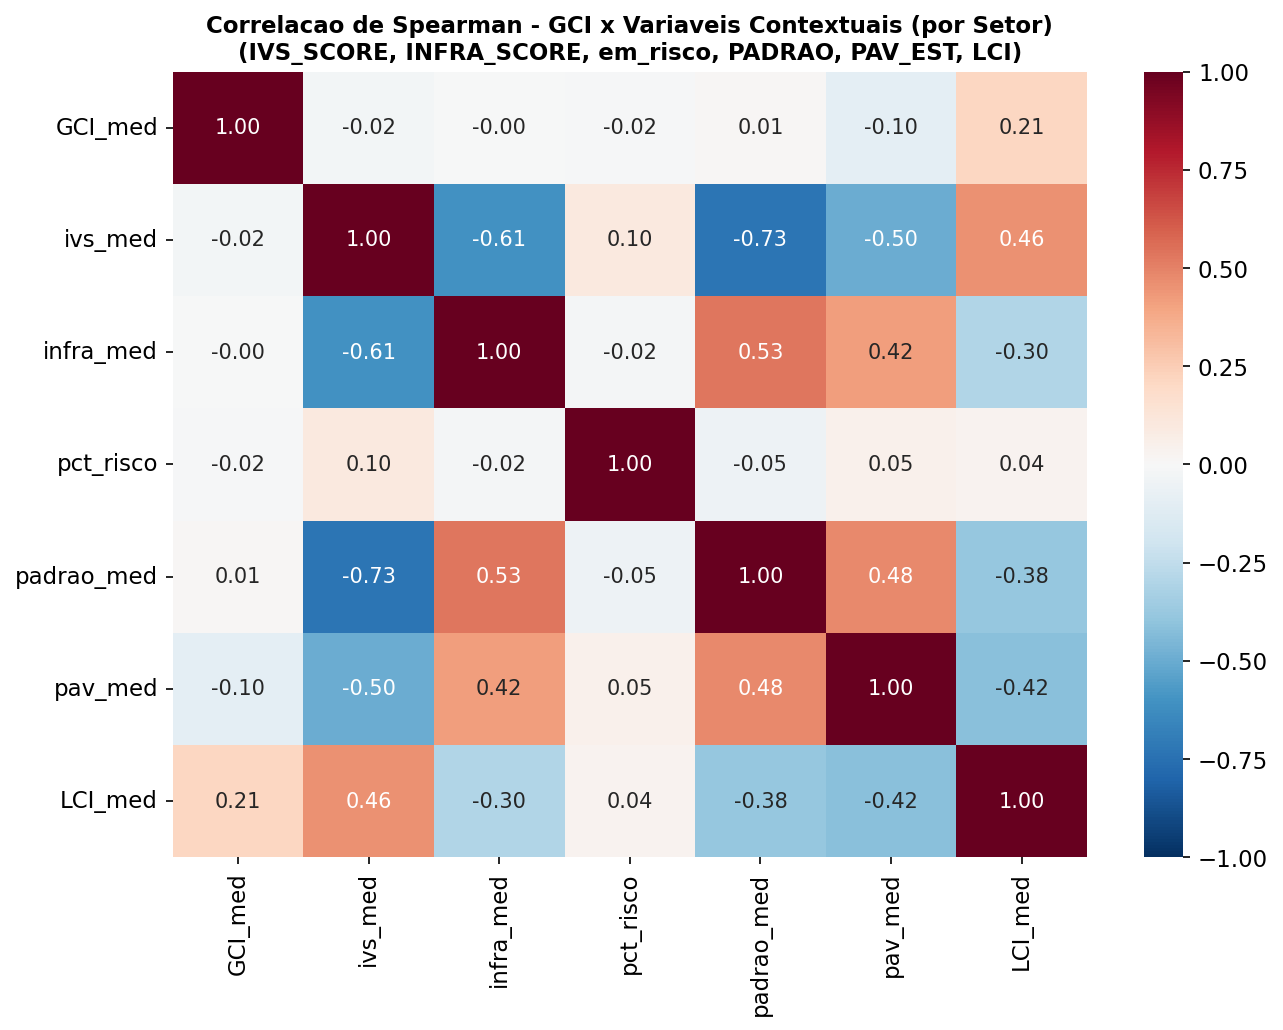


Correlacoes Spearman com GCI_med (por setor):
  GCI x ivs_med     : rho=-0.024 (n.s.) -
  GCI x infra_med   : rho=-0.004 (n.s.) -
  GCI x pct_risco   : rho=-0.015 (n.s.) -
  GCI x padrao_med  : rho=+0.010 (n.s.) +
  GCI x pav_med     : rho=-0.100 (***) -
  GCI x LCI_med     : rho=+0.212 (***) +


In [8]:
# 5.1 — Correlacao espacial multivariada: GCI x IVS_SCORE, INFRA_SCORE, em_risco por setor
try:
    from scipy import stats as scipy_stats
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import numpy as np

    v3_path_11 = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
    if not v3_path_11.exists():
        raise FileNotFoundError("cnefe_master_metrics.parquet nao encontrado — execute --from etl")

    gdf_v3_11 = gdf  # alias: parquet ja carregado no setup
    print(f"v3: {len(gdf_v3_11):,} registros x {gdf_v3_11.shape[1]} colunas")

    # Agregar por setor censitario
    ctx_agg_cols = {'GCI_med': ('GCI', 'median'), 'n': ('GCI', 'count')}
    for c, lbl in [('IVS_SCORE','ivs_med'), ('INFRA_SCORE','infra_med'),
                   ('em_risco','pct_risco'), ('PADRAO_SCORE','padrao_med'),
                   ('PAV_EST','pav_med')]:
        if c in gdf_v3_11.columns:
            ctx_agg_cols[lbl] = (c, 'mean')
    if 'LCI' in gdf_v3_11.columns:
        ctx_agg_cols['LCI_med'] = ('LCI', 'mean')

    setor_col_11 = 'COD_SETOR' if 'COD_SETOR' in gdf_v3_11.columns else gdf_v3_11.columns[0]
    setor_agg_11 = gdf_v3_11.groupby(setor_col_11).agg(**ctx_agg_cols).reset_index()
    setor_agg_11 = setor_agg_11[setor_agg_11['n'] >= 10]
    print(f"Setores com >= 10 registros: {len(setor_agg_11):,}")

    # Matriz de correlacao de Spearman
    ctx_feat_11 = [c for c in ['ivs_med','infra_med','pct_risco','padrao_med','pav_med','LCI_med']
                   if c in setor_agg_11.columns]
    corr_df = setor_agg_11[['GCI_med'] + ctx_feat_11].dropna()
    corr_matrix = corr_df.corr(method='spearman')

    fig_corr, ax_corr = plt.subplots(figsize=(9, 7))
    import seaborn as sns
    mask = np.zeros_like(corr_matrix, dtype=bool)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax_corr, mask=mask,
                annot_kws={'size': 10})
    ax_corr.set_title('Correlacao de Spearman - GCI x Variaveis Contextuais (por Setor)\n'
                      '(IVS_SCORE, INFRA_SCORE, em_risco, PADRAO, PAV_EST, LCI)',
                      fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_spearman_gci_contexto.png', dpi=180, bbox_inches='tight')
    plt.show()

    # Print significancia
    print("\nCorrelacoes Spearman com GCI_med (por setor):")
    for feat in ctx_feat_11:
        valid = corr_df[['GCI_med', feat]].dropna()
        rho, p = scipy_stats.spearmanr(valid['GCI_med'], valid[feat])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        direcao = '+' if rho > 0 else '-'
        print(f"  GCI x {feat:<12}: rho={rho:+.3f} ({sig}) {direcao}")

except Exception as e:
    print(f"5.1 skipped: {e}")

### 5.2 Spatial Error Model Expandido com Variáveis Contextuais

O SEM expandido incorpora IVS_SCORE, INFRA_SCORE, em_risco e PADRAO_SCORE ao modelo espacial. Verificamos se a inclusão de fatores contextuais reduz o lambda do SEM básico (Seção 4: lambda=0,3509). Uma redução de lambda indica que esses fatores explicam parte da autocorrelação espacial do GCI. Usa setores censitários como unidade de análise.

v3 carregado: 1,172,902 registros


Setores unicos em v3 (apos normalizacao): 5,125
Setores apos merge: 5,135 | gci_med preenchido: 4,807
Setores com dados completos: 4,598


('WARNING: ', 226, ' is an island (no neighbors)')
('WARNING: ', 394, ' is an island (no neighbors)')
('WARNING: ', 3584, ' is an island (no neighbors)')



=== OLS Expandido (features contextuais v3) ===
  R2: 0.0030
  AIC: -5557.74
  Moran I residuos: 0.0638 (p=0.0010)
  Features: ['ivs_med', 'infra_med', 'pct_risco', 'padrao_med']


ML_Error



=== Spatial Error Model Expandido ===
  Lambda: 0.1579
  AIC: -5604.66
  Melhora AIC vs OLS: 46.91
  Moran I residuos SEM: 0.0641 (p=0.0010)
  -> Residuos ainda autocorrelacionados


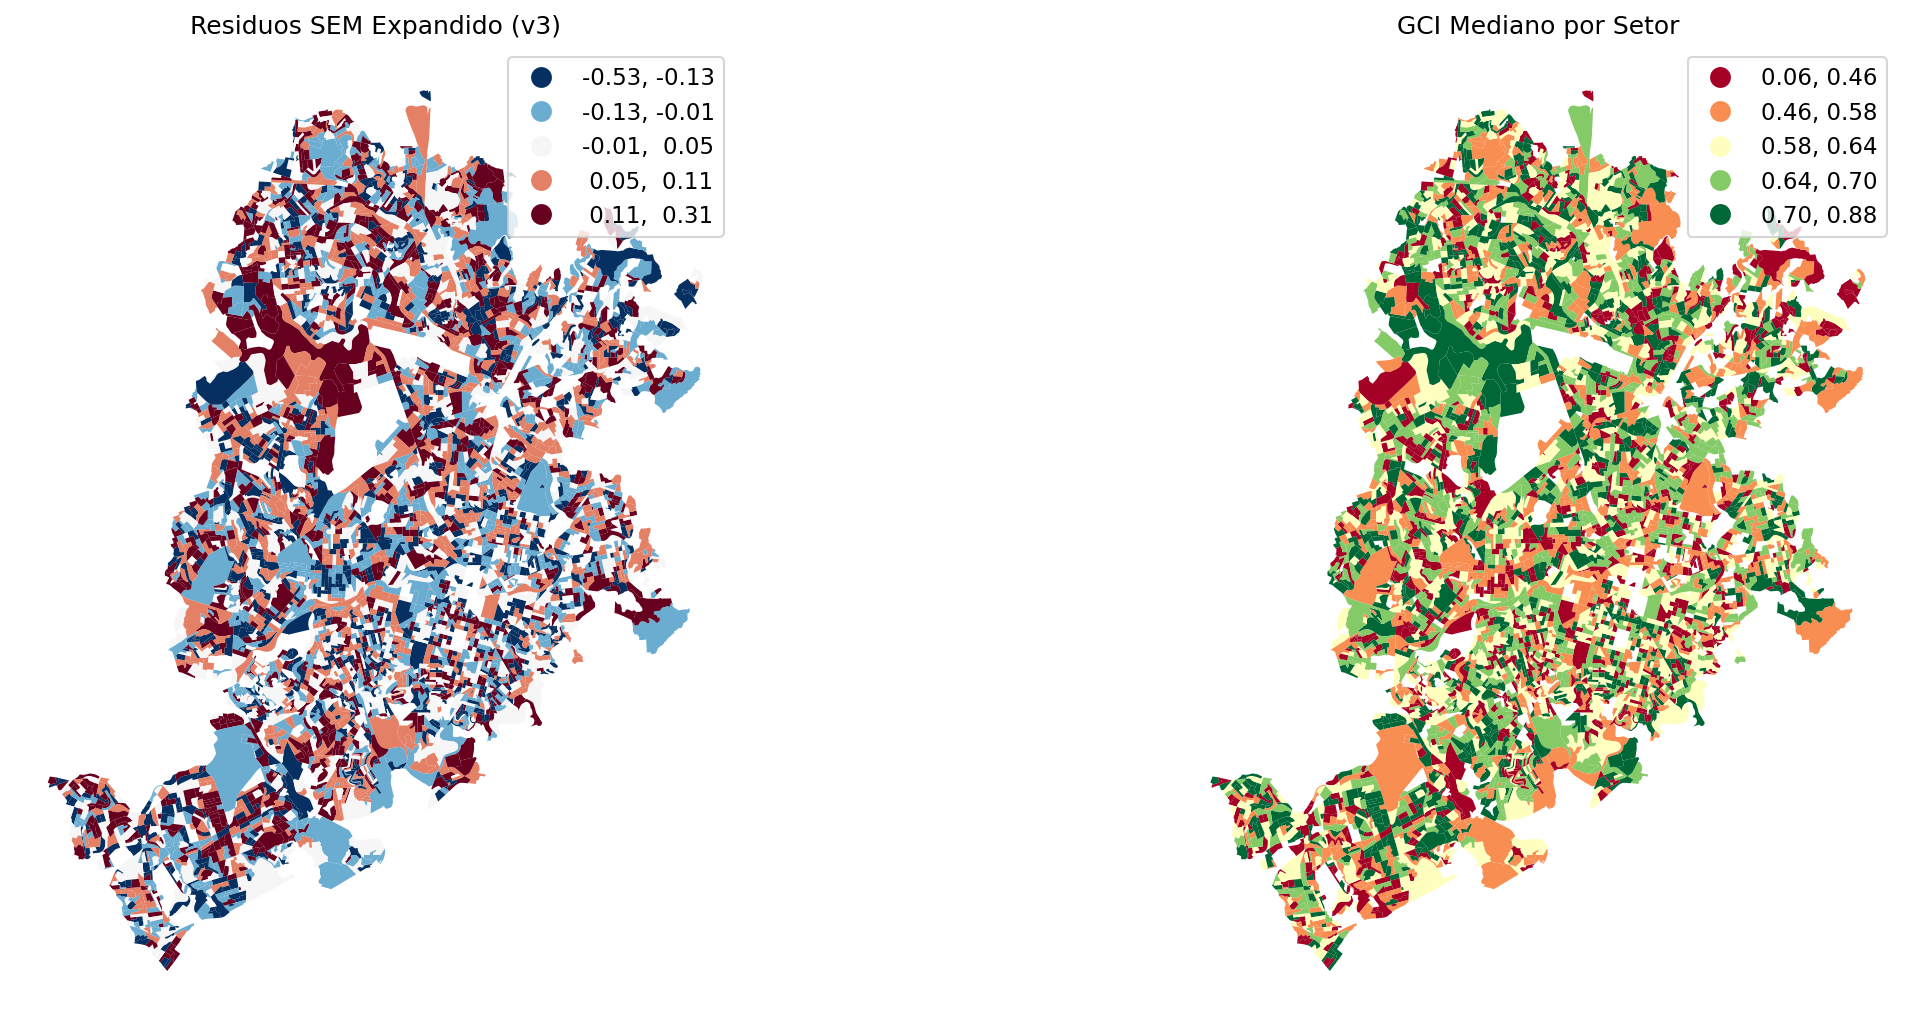

In [9]:
# 5.2 — SEM expandido com variaveis contextuais (IVS_SCORE, INFRA_SCORE, em_risco)
try:
    from spreg import OLS, ML_Error
    from esda.moran import Moran
    import libpysal
    import geopandas as gpd

    if 'setores_agg' not in dir() or len(setores_agg) < 10:
        raise ValueError("setores_agg nao disponivel — execute a célula da Seção 1 primeiro")

    v3_path_d = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
    if not v3_path_d.exists():
        raise FileNotFoundError("cnefe_master_metrics.parquet nao encontrado — execute --from etl")

    gdf_v3_d = gdf  # alias: parquet ja carregado no setup
    print(f"v3 carregado: {len(gdf_v3_d):,} registros")

    # Agregar por setor: GCI medio, IVS_SCORE medio, INFRA_SCORE medio, pct em_risco
    agg_cols_d = {'gci_med': ('GCI', 'median'), 'n': ('GCI', 'count')}
    if 'IVS_SCORE'    in gdf_v3_d.columns: agg_cols_d['ivs_med']    = ('IVS_SCORE', 'mean')
    if 'INFRA_SCORE'  in gdf_v3_d.columns: agg_cols_d['infra_med']  = ('INFRA_SCORE', 'mean')
    if 'em_risco'     in gdf_v3_d.columns: agg_cols_d['pct_risco']  = ('em_risco', 'mean')
    if 'PADRAO_SCORE' in gdf_v3_d.columns: agg_cols_d['padrao_med'] = ('PADRAO_SCORE', 'mean')

    setor_col_d = 'COD_SETOR' if 'COD_SETOR' in gdf_v3_d.columns else None
    if setor_col_d is None:
        raise ValueError("COD_SETOR nao encontrado em v3")

    agg_v3 = gdf_v3_d.groupby(setor_col_d).agg(**agg_cols_d).reset_index()

    # Normaliza COD_SETOR: registros CNEFE tem sufixos 'P'/'S' ausentes no shapefile de setores
    # (mesmo tratamento aplicado em A4 com str.rstrip('P').rstrip('S'))
    agg_v3[setor_col_d] = agg_v3[setor_col_d].astype(str).str.rstrip('P').str.rstrip('S')
    print(f"Setores unicos em v3 (apos normalizacao): {agg_v3[setor_col_d].nunique():,}")

    setores_d = setores_agg.copy()
    if 'COD_SETOR' in setores_d.columns:
        setores_d['COD_SETOR'] = setores_d['COD_SETOR'].astype(str).str.rstrip('P').str.rstrip('S')
        setores_d = setores_d.merge(agg_v3, on='COD_SETOR', how='left', suffixes=('', '_v3'))
    else:
        setores_d = setores_d.merge(agg_v3, left_on='COD_SETOR', right_on=setor_col_d,
                                    how='left', suffixes=('', '_v3'))

    print(f"Setores apos merge: {len(setores_d):,} | gci_med preenchido: {setores_d['gci_med'].notna().sum():,}")

    X_cols_d = [c for c in ['ivs_med', 'infra_med', 'pct_risco', 'padrao_med', 'n_safe']
                if c in setores_d.columns]
    if not X_cols_d:
        raise ValueError("Nenhuma feature contextual disponivel para SEM expandido")

    gci_col_d = 'gci_med' if ('gci_med' in setores_d.columns and setores_d['gci_med'].notna().any()) else 'GCI_mean'
    setores_d_clean = setores_d.dropna(subset=[gci_col_d] + X_cols_d).copy()
    setores_d_clean = setores_d_clean[setores_d_clean.geometry.is_valid].reset_index(drop=True)
    print(f"Setores com dados completos: {len(setores_d_clean):,}")

    y_d = setores_d_clean[gci_col_d].values.reshape(-1, 1)
    X_d = setores_d_clean[X_cols_d].fillna(0).values

    w_d = libpysal.weights.Queen.from_dataframe(setores_d_clean)
    w_d.transform = 'r'

    # OLS baseline
    ols_d = OLS(y_d, X_d, name_y='GCI', name_x=X_cols_d, w=w_d)
    moran_ols = Moran(ols_d.u.flatten(), w_d)
    print(f"\n=== OLS Expandido (features contextuais v3) ===")
    print(f"  R2: {ols_d.r2:.4f}")
    print(f"  AIC: {ols_d.aic:.2f}")
    print(f"  Moran I residuos: {moran_ols.I:.4f} (p={moran_ols.p_sim:.4f})")
    print(f"  Features: {X_cols_d}")

    # Spatial Error Model
    sem_d = ML_Error(y_d, X_d, w=w_d, name_y='GCI', name_x=X_cols_d)
    moran_sem_d = Moran(sem_d.u.flatten(), w_d)
    print(f"\n=== Spatial Error Model Expandido ===")
    print(f"  Lambda: {sem_d.lam:.4f}")
    print(f"  AIC: {sem_d.aic:.2f}")
    print(f"  Melhora AIC vs OLS: {ols_d.aic - sem_d.aic:.2f}")
    print(f"  Moran I residuos SEM: {moran_sem_d.I:.4f} (p={moran_sem_d.p_sim:.4f})")
    print(f"  -> Residuos {'ainda autocorrelacionados' if moran_sem_d.p_sim < 0.05 else 'limpos (sem autocorrelacao residual)'}")

    setores_d_clean = setores_d_clean.copy()
    setores_d_clean['sem_res_v3'] = sem_d.u.flatten()
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    setores_d_clean.plot(column='sem_res_v3', cmap='RdBu_r', legend=True,
                         ax=axes[0], edgecolor='none', scheme='quantiles', k=5)
    axes[0].set_title('Residuos SEM Expandido (v3)', fontsize=12)
    axes[0].set_axis_off()
    setores_d_clean.plot(column=gci_col_d, cmap='RdYlGn', legend=True,
                         ax=axes[1], edgecolor='none', scheme='quantiles', k=5)
    axes[1].set_title('GCI Mediano por Setor', fontsize=12)
    axes[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_sem_expandido.png', dpi=200, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"5.2 skipped: {e}")
    import traceback; traceback.print_exc()

Lambda do SEM expandido = 0,1579 (vs 0,3509 no SEM básico), redução relevante. O OLS expandido mantém R²=0,0030 (IVS, INFRA, em_risco e PADRAO explicam pouco da variação por setor) e o Moran dos resíduos cai para 0,0641 (p=0,001), bem abaixo do SEM básico (0,1460).

As variáveis contextuais BHMap reduzem a autocorrelação espacial residual (λ de 0,35 para 0,16), mas a estrutura espacial remanescente é pequena. O sinal contextual por setor é fraco, consistente com o predomínio do mecanismo de verticalização sobre os fatores socioespaciais.

## Anatomia das Inconsistencias: Decomposicao da Cauda de Erro

Salles et al. (2025) inspecionaram manualmente 68 enderecos discrepantes (>150 m)
entre CNEFE e Prodabel e observaram que o CNEFE tende a apontar para enderecos
proximos, mas incorretos, na mesma rua. Aqui essa investigacao e automatizada e
levada a escala: para todos os pares com erro acima de 25 m, decompomos a cauda de
erro em tres causas e medimos a coerencia direcional do deslocamento por rua. Uma
coerencia alta (vetores apontando na mesma direcao) indica um deslocamento
sistematico, compativel com uma diferenca de convencao de posicionamento entre as
bases (o CNEFE registra o acesso a edificacao; o cadastro municipal, a posicao
metrica ou a ordenacao sequencial do lote), e nao ruido de GPS.

,N,%,erro_mediano_m
causa,,,
Deslocamento sistematico de rua,51532,57.0,40.4
Ruido isolado,37482,41.5,35.1
Colapso de coordenadas,1355,1.5,38.1


Pares com erro > 25 m: 90,369 (7.7%)
Ruas com >=5 pares de alto erro: 2,063 | coerencia direcional mediana: 0.85
  65% com offset sistematico (coerencia > 0,7); 10% ruido (coerencia < 0,3)


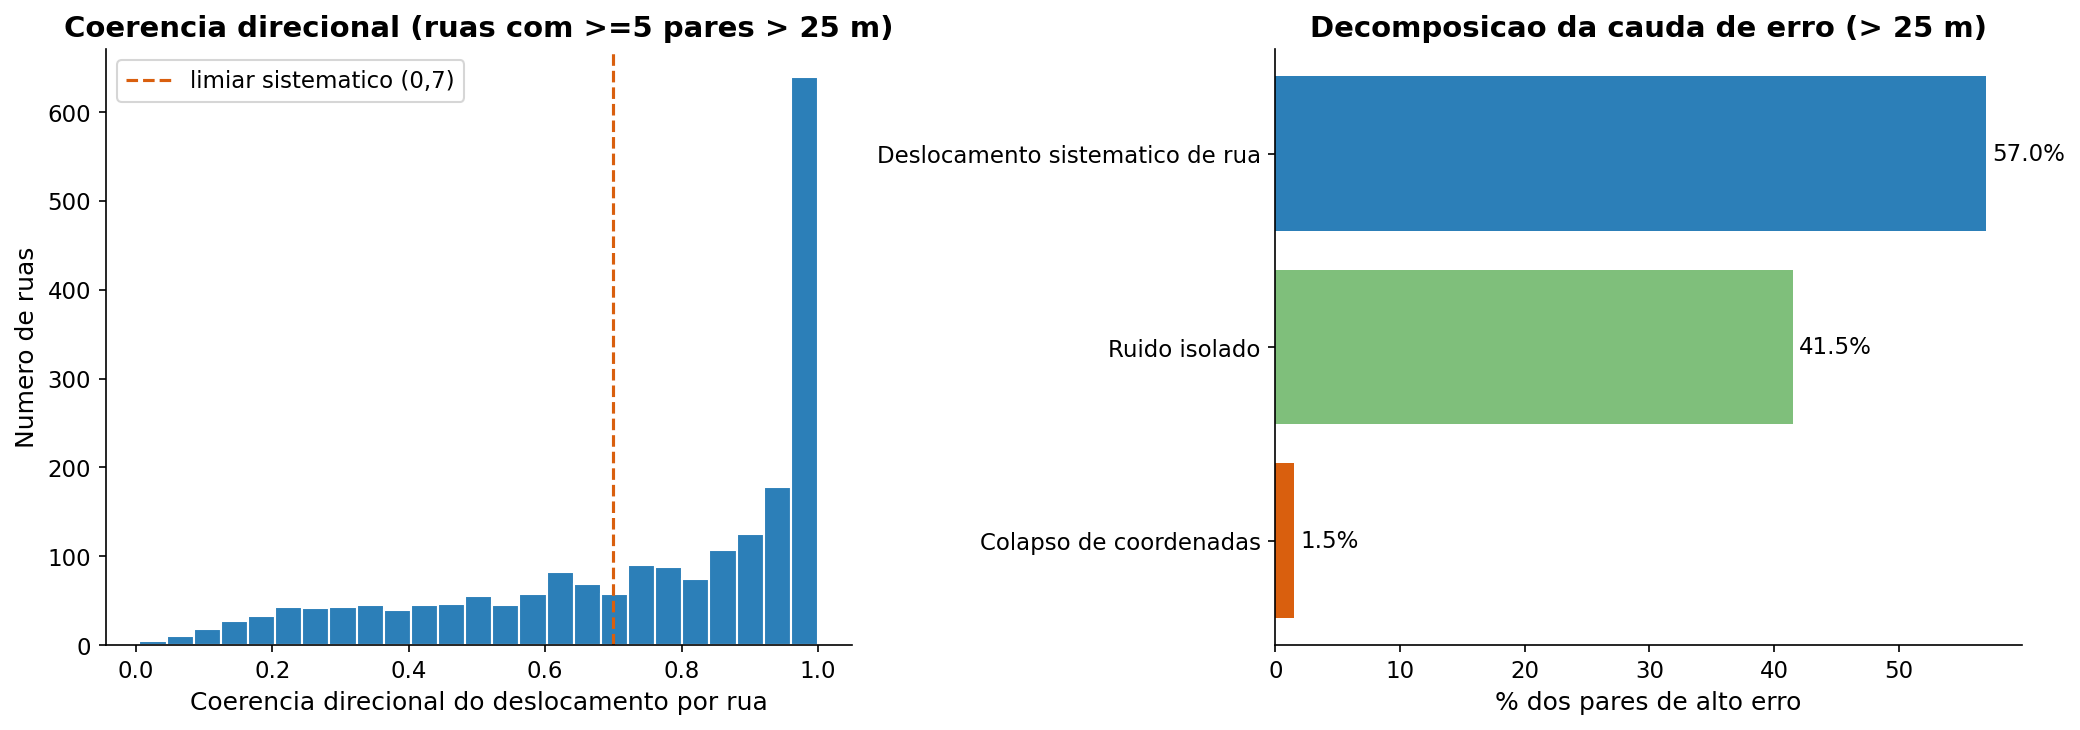

In [10]:
# Anatomia das inconsistencias: decomposicao da cauda de erro (escala de Salles et al. 2025)
import numpy as np

g = gdf.dropna(subset=['match_distance']).copy()
g['dx'] = g['bhmap_geom'].x - g.geometry.x
g['dy'] = g['bhmap_geom'].y - g.geometry.y

HI = 25  # limiar de alto erro (m)
hi = g[g['match_distance'] > HI].copy()

def _coh(grp):
    R = np.hypot(grp['dx'].sum(), grp['dy'].sum())
    S = np.hypot(grp['dx'], grp['dy']).sum()
    return R / S if S > 0 else np.nan

csize = hi.groupby('LOGRA_BH').size()
ccoh = hi.groupby('LOGRA_BH').apply(lambda x: _coh(x) if len(x) >= 5 else np.nan)
hi['rua_n'] = hi['LOGRA_BH'].map(csize)
hi['rua_coh'] = hi['LOGRA_BH'].map(ccoh)

def _causa(r):
    if r['cdi'] > 5:
        return 'Colapso de coordenadas'
    if r['rua_n'] >= 5 and r['rua_coh'] > 0.7:
        return 'Deslocamento sistematico de rua'
    return 'Ruido isolado'

hi['causa'] = hi.apply(_causa, axis=1)
ordem = ['Deslocamento sistematico de rua', 'Ruido isolado', 'Colapso de coordenadas']
dec = hi['causa'].value_counts().reindex(ordem)
tab = pd.DataFrame({
    'N': dec,
    '%': (dec / len(hi) * 100).round(1),
    'erro_mediano_m': hi.groupby('causa')['match_distance'].median().reindex(ordem).round(1),
})
tab.to_csv(config.TAB_DIR / 'nb11_anatomia_inconsistencias.csv')
display(tab)

coh_valid = ccoh.dropna()
print(f"Pares com erro > {HI} m: {len(hi):,} ({len(hi)/len(g)*100:.1f}%)")
print(f"Ruas com >=5 pares de alto erro: {len(coh_valid):,} | coerencia direcional mediana: {coh_valid.median():.2f}")
print(f"  {(coh_valid > 0.7).mean()*100:.0f}% com offset sistematico (coerencia > 0,7); "
      f"{(coh_valid < 0.3).mean()*100:.0f}% ruido (coerencia < 0,3)")

colors = {'Deslocamento sistematico de rua': '#2c7fb8', 'Ruido isolado': '#7fbf7b',
          'Colapso de coordenadas': '#d95f0e'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(coh_valid, bins=25, color='#2c7fb8', edgecolor='white')
axes[0].axvline(0.7, color='#d95f0e', ls='--', label='limiar sistematico (0,7)')
axes[0].set_xlabel('Coerencia direcional do deslocamento por rua')
axes[0].set_ylabel('Numero de ruas')
axes[0].set_title('Coerencia direcional (ruas com >=5 pares > 25 m)', fontweight='bold')
axes[0].legend()
axes[1].barh(list(tab.index), list(tab['%']), color=[colors[c] for c in tab.index])
axes[1].invert_yaxis()
axes[1].set_xlabel('% dos pares de alto erro')
axes[1].set_title('Decomposicao da cauda de erro (> 25 m)', fontweight='bold')
for i, (idx, row) in enumerate(tab.iterrows()):
    axes[1].text(row['%'] + 0.5, i, f"{row['%']:.1f}%", va='center')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb11_anatomia_inconsistencias.png', dpi=200, bbox_inches='tight')
plt.show()


### Hotspots do Erro Posicional (Getis-Ord Gi*, inspirado em Fisher et al. 2021)

Fisher et al. (2021) usaram uma funcao de risco relativo espacial ponderada pelo erro
para localizar areas de erro significativamente maior. Aqui aplicamos o analogo em Python,
a estatistica Getis-Ord Gi* sobre o erro mediano por setor censitario, para mapear
hotspots (concentracoes de erro alto) e coldspots (erro baixo).

,classe,n_setores
0,nao significativo,4067
1,coldspot (erro baixo),773
2,hotspot (erro alto),295


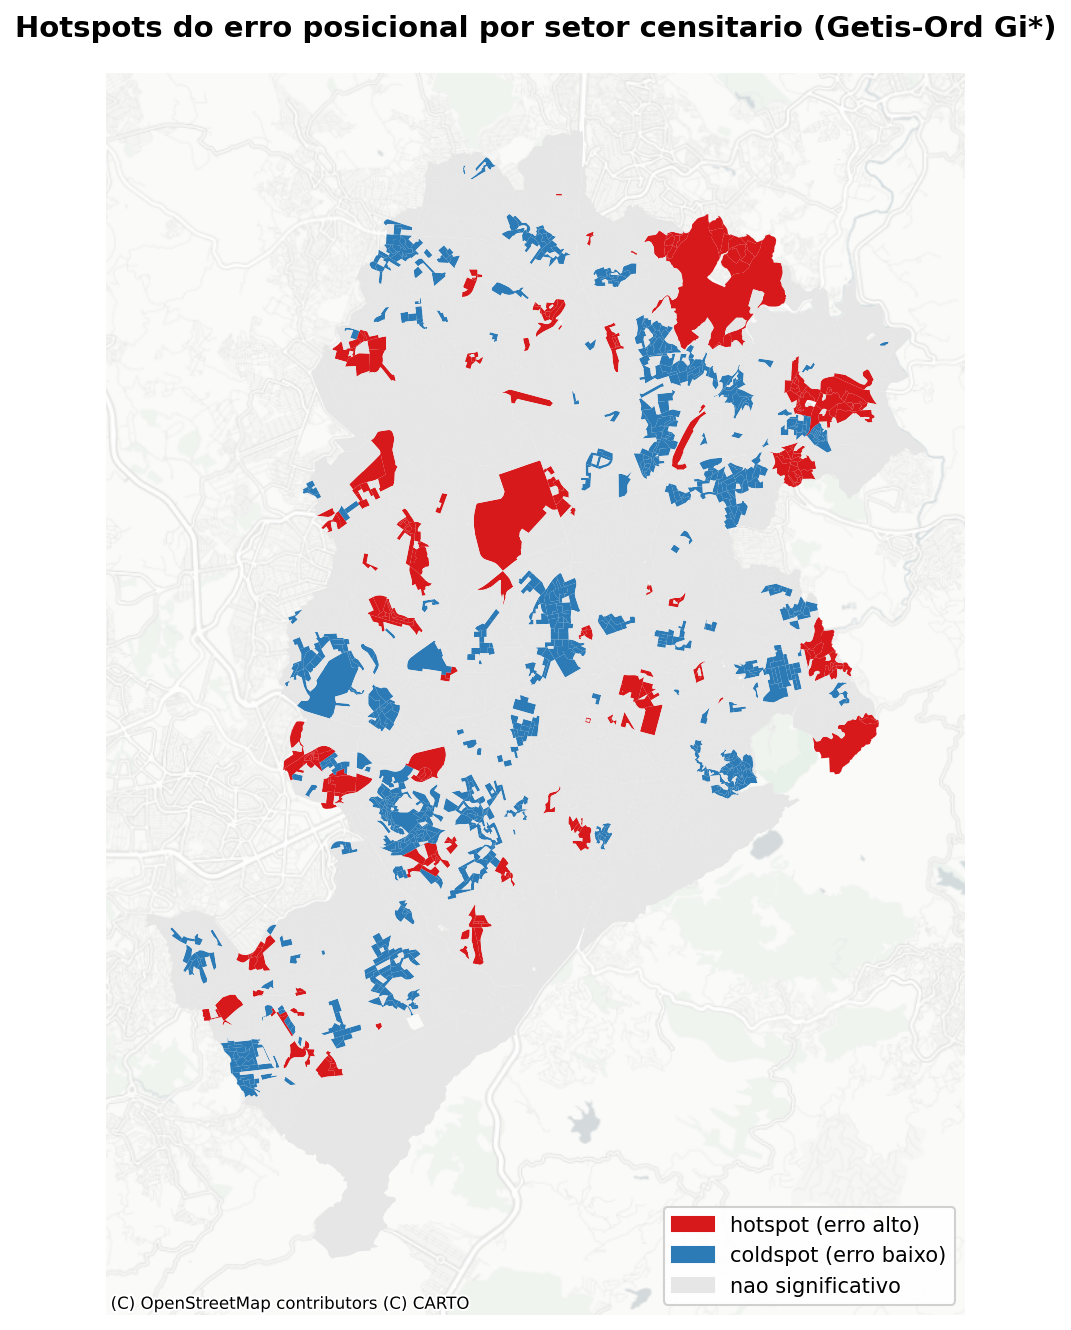

In [11]:
# Hotspot do erro posicional por setor (Getis-Ord Gi*)
import libpysal
from esda.getisord import G_Local
from matplotlib.patches import Patch

setores_h = gpd.read_file(config.SETOR_CENSITARIO_SHP).to_crs(config.TARGET_CRS)
gdf_h = gdf.dropna(subset=['match_distance']).copy()
if 'index_right' in gdf_h.columns:
    gdf_h = gdf_h.drop(columns='index_right')
gdf_h = gpd.sjoin(gdf_h, setores_h[['geometry']], how='left', predicate='within')
setor_err = (gdf_h.groupby('index_right')
             .agg(err_med=('match_distance', 'median'), n=('match_distance', 'size'))
             .reset_index())
sa = setores_h.merge(setor_err, left_index=True, right_on='index_right', how='left')
sa = sa[sa['n'].fillna(0) >= 10].copy()
sa['err_med'] = sa['err_med'].fillna(sa['err_med'].median())
sa = sa[sa.geometry.is_valid].reset_index(drop=True)

wg = libpysal.weights.Queen.from_dataframe(sa)
wg.transform = 'r'
gi = G_Local(sa['err_med'].values, wg, permutations=999, star=True)
sa['gi_z'] = gi.Zs
sa['gi_p'] = gi.p_sim
sa['classe'] = 'nao significativo'
sa.loc[(sa['gi_p'] < 0.05) & (sa['gi_z'] > 0), 'classe'] = 'hotspot (erro alto)'
sa.loc[(sa['gi_p'] < 0.05) & (sa['gi_z'] < 0), 'classe'] = 'coldspot (erro baixo)'

res_gi = sa['classe'].value_counts().rename_axis('classe').reset_index(name='n_setores')
res_gi.to_csv(config.TAB_DIR / 'nb11_hotspot_erro.csv', index=False)
display(res_gi)

cores = {'hotspot (erro alto)': '#d7191c', 'coldspot (erro baixo)': '#2c7bb6',
         'nao significativo': '#e6e6e6'}
fig, ax = plt.subplots(figsize=(9, 9))
for cl, col in cores.items():
    sub = sa[sa['classe'] == cl]
    if len(sub):
        sub.plot(ax=ax, color=col, edgecolor='none')
ax.set_title('Hotspots do erro posicional por setor censitario (Getis-Ord Gi*)',
             fontweight='bold')
handles = [Patch(color=cores[cl], label=cl) for cl in cores if (sa['classe'] == cl).any()]
ax.legend(handles=handles, loc='lower right', fontsize=10, framealpha=0.9)
ax.axis('off')
try:
    import contextily as cx
    cx.add_basemap(ax, crs=sa.crs.to_string(), source=cx.providers.CartoDB.PositronNoLabels)
except Exception as e:
    print('basemap indisponivel:', e)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb11_hotspot_erro.png', dpi=200, bbox_inches='tight')
plt.show()


### Exemplo de Deslocamento Sistematico numa Rua (estilo Salles et al. 2025, Fig. 4)

Para ilustrar o deslocamento sistematico dominante na cauda de erro, seleciona-se uma rua
com alta coerencia direcional e desenham-se os vetores que ligam a coordenada do CNEFE a do
BHMap para cada endereco, no formato usado por Salles et al. (2025).

In [ ]:
# Mapa de exemplo: deslocamento sistematico numa rua (vetores CNEFE -> BHMap)
import numpy as np
import contextily as cx

gv = gdf.dropna(subset=['match_distance']).copy()
gv['dx'] = gv['bhmap_geom'].x - gv.geometry.x
gv['dy'] = gv['bhmap_geom'].y - gv.geometry.y
hiv = gv[gv['match_distance'] > 25].copy()

def _coh(g):
    R = np.hypot(g['dx'].sum(), g['dy'].sum())
    S = np.hypot(g['dx'], g['dy']).sum()
    return R / S if S > 0 else np.nan

# rua com pontos espalhados ao longo do segmento E deslocamento coerente
cand = []
for rua_i, g in hiv.groupby('LOGRA_BH'):
    n = len(g)
    if n < 15 or n > 60:
        continue
    c = _coh(g)
    if c is None or not (0.75 < c < 0.98):
        continue
    ext = float(np.hypot(g.geometry.x.max() - g.geometry.x.min(),
                         g.geometry.y.max() - g.geometry.y.min()))
    if not (150 <= ext <= 500):
        continue
    n_coords = g.geometry.apply(lambda p: (round(p.x), round(p.y))).nunique()
    if n_coords < 15:  # exige coordenadas distintas (evita colapso)
        continue
    cand.append((rua_i, n, float(c)))
cand.sort(key=lambda t: -t[1])
rua = cand[0][0] if cand else hiv['LOGRA_BH'].value_counts().index[0]

sub = hiv[hiv['LOGRA_BH'] == rua].copy()
cn_x, cn_y = sub.geometry.x.values, sub.geometry.y.values
bh = gpd.GeoSeries(sub['bhmap_geom'].values, crs=gv.crs)
bh_x, bh_y = bh.x.values, bh.y.values

fig, ax = plt.subplots(figsize=(9, 9))
for px, py, qx, qy in zip(cn_x, cn_y, bh_x, bh_y):
    ax.annotate('', xy=(qx, qy), xytext=(px, py),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.3))
ax.scatter(cn_x, cn_y, c='black', s=18, zorder=3, label='CNEFE (IBGE)')
ax.scatter(bh_x, bh_y, c='#2c7bb6', s=18, zorder=3, label='BHMap (Prodabel)')
allx = np.r_[cn_x, bh_x]
ally = np.r_[cn_y, bh_y]
padx = (allx.max() - allx.min()) * 0.12 + 15
pady = (ally.max() - ally.min()) * 0.12 + 15
ax.set_xlim(allx.min() - padx, allx.max() + padx)
ax.set_ylim(ally.min() - pady, ally.max() + pady)
ax.set_title(f'Deslocamento sistematico: {rua} (n={len(sub)}, coerencia={_coh(sub):.2f})',
             fontweight='bold')
ax.legend(loc='best')
ax.axis('off')
try:
    cx.add_basemap(ax, crs=gv.crs.to_string(), source=cx.providers.CartoDB.Positron)
except Exception as e:
    print('basemap indisponivel:', e)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb11_rua_offset_exemplo.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Rua exemplo: {rua} | n={len(sub)} | coerencia={_coh(sub):.2f}")


## Conclusão do Notebook 11

As abordagens convergem para um quadro de estrutura espacial fraca:
- **LISA:** Moran global I=0,1494 (p=0,001); após correção FDR, nenhum cluster local sobrevive, a aglomeração é estatisticamente frágil.
- **5.1 (Spearman por setor):** apenas PAV_EST (ρ=−0,100) e LCI (ρ=+0,212) são significativos; IVS, INFRA, em_risco e PADRAO_SCORE são não-significativos no nível de setor. O contexto socioeconômico tem efeito desprezível sobre o GCI agregado.
- **5.2 (SEM):** o lambda cai de 0,3509 (básico) para 0,1579 (expandido) e o Moran dos resíduos de 0,1460 para 0,0641. As variáveis contextuais absorvem parte de uma autocorrelação que já era baixa.

Resultado conjunto: a qualidade do CNEFE é espacialmente estruturada de forma fraca. A heterogeneidade dominante é intra-bairro (verticalização por edifício), não macro-espacial, o que reforça a quase uniformidade do GCI_empírico entre regionais discutida no NB13. **H3 (dependência espacial) é ACEITA porém com efeito fraco (I=0,1494), não moderado.**